# Deep Multimodal Fraud Detection = EfficientNet-B0

Late fusion: CNN image branch + tabular MLP branch, combined via fusion head.


4 experiments (2×2 ablation):

- **A** Raw features, normal training

- **B** Raw features, WeightedRandomSampler

- **C** Engineered features, normal training

- **D** Engineered features, WeightedRandomSampler


Threshold: **minimum expected cost** (FN × $50,000 + FP × $500).


In [1]:
import sys, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

from multimodal_utils import (
    MultimodalFraudDetector,
    engineer_features, validate_features,
    TAB_RAW, TAB_ALL_FE, TARGET_COL,
    fit_scaler, build_dataloaders,
    make_loss_fn, fit_model, predict_probs,
    subgroup_by_combo,
)

def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False

SEED   = 42
set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}  |  PyTorch {torch.__version__}")


Device : cpu  |  PyTorch 2.11.0+cpu


In [2]:
PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data" / "processed"

BACKBONE = "efficientnet_b0"

TRAIN_CSV = DATA_DIR / "mm_train_mixed_all_group_test.csv"
VAL_CSV   = DATA_DIR / "mm_val_mixed_all_group_test.csv"
TEST_CSV  = DATA_DIR / "mm_test_mixed_all_group_test.csv"

BATCH_SIZE      = 32
NUM_WORKERS     = 0
STAGE1_EPOCHS   = 5;   STAGE1_LR   = 1e-3;  STAGE1_PATIENCE = 5
STAGE2_EPOCHS   = 20;  BACKBONE_LR = 1e-5;  HEAD_LR         = 1e-4
STAGE2_PATIENCE = 6

RESULTS_BASE = PROJECT_ROOT / "notebook" / "results" / f"mm_deep_{BACKBONE}"
EXP_DIRS = {
    "A_raw_normal":  RESULTS_BASE / "A_raw_normal",
    "B_raw_sampler": RESULTS_BASE / "B_raw_sampler",
    "C_fe_normal":   RESULTS_BASE / "C_fe_normal",
    "D_fe_sampler":  RESULTS_BASE / "D_fe_sampler",
}
for d in EXP_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

COMBO_COLOURS = {"tab0_img0":"#4C72B0","tab1_img1":"#C44E52",
                 "tab1_img0":"#DD8452","tab0_img1":"#55A868"}

print(f"Backbone    : {BACKBONE}")
print(f"Results base: {RESULTS_BASE}")


Backbone    : efficientnet_b0
Results base: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_efficientnet_b0


# Deep multimodal baseline - EfficientNet-B0


In [3]:
train_raw = pd.read_csv(TRAIN_CSV)
val_raw   = pd.read_csv(VAL_CSV)
test_raw  = pd.read_csv(TEST_CSV)

train_fe = engineer_features(train_raw)
val_fe   = engineer_features(val_raw)
test_fe  = engineer_features(test_raw)

validate_features(TAB_RAW)
validate_features(TAB_ALL_FE)
print("Feature validation passed — no label leakage.")

scaler_raw = fit_scaler(train_raw, TAB_RAW)
scaler_fe  = fit_scaler(train_fe,  TAB_ALL_FE)

print(f"\nTrain: {len(train_raw):,} | Val: {len(val_raw):,} | Test: {len(test_raw):,}")
print(f"Raw features ({len(TAB_RAW)}): {TAB_RAW}")
print(f"Engineered features ({len(TAB_ALL_FE)}): {TAB_ALL_FE}")
print("\nTrain class counts:")
print(train_raw[TARGET_COL].value_counts())


Feature validation passed — 7 features, no leakage.
Feature validation passed — 12 features, no leakage.
Feature validation passed — no label leakage.
Feature validation passed — 7 features, no leakage.
Scaler fitted on 7 features: ['tab_type', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud']
Feature validation passed — 12 features, no leakage.
Scaler fitted on 12 features: ['tab_type', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_balance_delta_orig', 'tab_balance_delta_dest', 'tab_amount_ratio_orig', 'tab_amount_ratio_dest', 'tab_orig_balance_zeroed']

Train: 7,182 | Val: 1,508 | Test: 1,474
Raw features (7): ['tab_type', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud']
Engineered features (12): ['tab_type', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalance

## Imbalance analysis

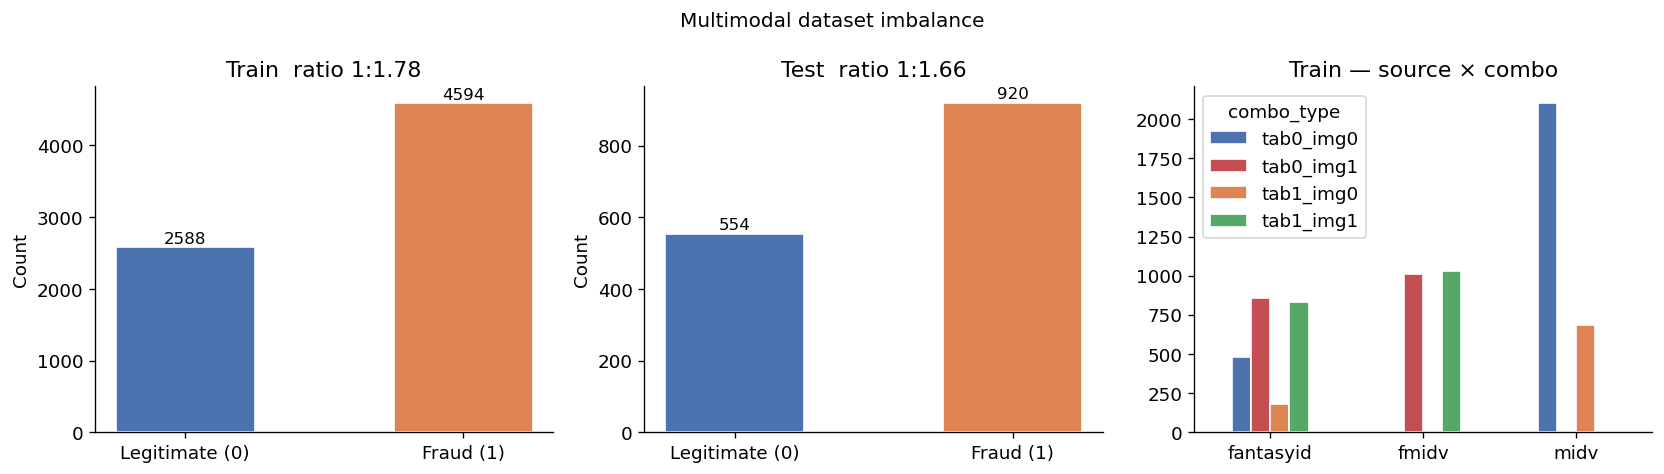

pos_weight = 2588/4594 = 0.563  (DOWN-weights fraud = majority class)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, df) in zip(axes[:2], [("Train",train_raw),("Test",test_raw)]):
    counts = df[TARGET_COL].value_counts().sort_index()
    bars = ax.bar(["Legitimate (0)","Fraud (1)"], counts.values,
                  color=["#4C72B0","#DD8452"], edgecolor="white", width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                str(val), ha="center", va="bottom", fontsize=10)
    ratio = counts.get(1,0)/max(counts.get(0,1),1)
    ax.set_title(f"{name}  ratio 1:{ratio:.2f}"); ax.set_ylabel("Count")
    ax.spines[["top","right"]].set_visible(False)
if "img_source_dataset" in train_raw.columns:
    pd.crosstab(train_raw["img_source_dataset"],
                train_raw["combo_type"]).plot(
        kind="bar", ax=axes[2],
        color=list(COMBO_COLOURS.values()), edgecolor="white")
    axes[2].set_title("Train — source × combo"); axes[2].set_xlabel("")
    axes[2].tick_params(axis="x", rotation=0)
    axes[2].spines[["top","right"]].set_visible(False)
fig.suptitle("Multimodal dataset imbalance", fontsize=12)
fig.tight_layout(); plt.show()
n0 = (train_raw[TARGET_COL]==0).sum(); n1 = (train_raw[TARGET_COL]==1).sum()
print(f"pos_weight = {n0}/{n1} = {n0/n1:.3f}  (DOWN-weights fraud = majority class)")


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, auc as sk_auc,
    confusion_matrix, ConfusionMatrixDisplay,
)

FN_COST = 50_000
FP_COST = 500

def evaluate_mm_model(y_true, y_prob, split_name="split", threshold=0.5):
    """Mirrors evaluate_model() from tabular utils."""
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "split":     split_name,
        "accuracy":  float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true,    y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true,        y_pred, zero_division=0)),
        "roc_auc":   float(roc_auc_score(y_true, y_prob)),
        "pr_auc":    float(average_precision_score(y_true, y_prob)),
    }
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n=== {split_name.upper()} ===")
    for k, v in metrics.items():
        if k != "split": print(f"{k}: {v:.6f}")
    print("\nConfusion matrix:"); print(cm)
    return metrics, cm

def search_thresholds_mm(y_true, y_prob,
                          thresholds=np.arange(0.10, 1.00, 0.05)):
    """Mirrors search_thresholds() from tabular utils."""
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold":       round(float(t), 4),
            "precision":       float(precision_score(y_true, y_pred, zero_division=0)),
            "recall":          float(recall_score(y_true,    y_pred, zero_division=0)),
            "f1":              float(f1_score(y_true,        y_pred, zero_division=0)),
            "predicted_fraud": int(y_pred.sum()),
        })
    return pd.DataFrame(rows)

def compute_cost_table_mm(threshold_results, y_val_true,
                           fn_cost=FN_COST, fp_cost=FP_COST):
    """Mirrors compute_cost_table() from tabular utils."""
    n_pos = int((y_val_true == 1).sum())
    n_neg = int((y_val_true == 0).sum())
    rows = []
    for _, row in threshold_results.iterrows():
        tp = round(row["recall"] * n_pos)
        fn = n_pos - tp
        fp = row["predicted_fraud"] - tp
        tn = n_neg - fp
        rows.append({
            "threshold":       row["threshold"],
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision":       row["precision"],
            "recall":          row["recall"],
            "f1":              row["f1"],
            "predicted_fraud": row["predicted_fraud"],
            "expected_cost":   int(fn * fn_cost + fp * fp_cost),
        })
    return pd.DataFrame(rows).sort_values("expected_cost").reset_index(drop=True)

def evaluate_mm_with_threshold(y_true, y_prob, threshold):
    """Mirrors evaluate_with_threshold() from tabular utils."""
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    metrics = {
        "threshold": float(threshold),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true,    y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true,        y_pred, zero_division=0)),
    }
    print(f"\nTuned threshold: {threshold}")
    print(f"Precision: {metrics['precision']:.6f}")
    print(f"Recall:    {metrics['recall']:.6f}")
    print(f"F1:        {metrics['f1']:.6f}")
    print("\nConfusion matrix:"); print(cm)
    return metrics, cm

def compute_expected_cost_from_cm(cm, fn_cost=FN_COST, fp_cost=FP_COST):
    """Mirrors compute_expected_cost_from_cm() from tabular utils."""
    tn, fp, fn, tp = cm.ravel()
    return {"tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
            "expected_cost": int(fn * fn_cost + fp * fp_cost)}

def save_mm_experiment_outputs(results_dir, test_y_true, test_y_prob,
                                threshold_results, cost_df,
                                tuned_metrics, tuned_cm,
                                val_metrics, test_metrics, prefix,
                                subgroup_df=None):
    """Mirrors save_experiment_outputs() from tabular utils."""
    from pathlib import Path
    results_dir = Path(results_dir)
    pred_df = pd.DataFrame({"y_true": test_y_true, "y_prob": test_y_prob})
    pred_df["y_pred"] = (pred_df["y_prob"] >= tuned_metrics["threshold"]).astype(int)
    pred_df.to_csv(results_dir / "test_predictions.csv", index=False)
    threshold_results.to_csv(results_dir / f"{prefix}_threshold_results.csv", index=False)
    cost_df.to_csv(results_dir / f"{prefix}_cost_results.csv", index=False)
    pd.DataFrame([tuned_metrics]).to_csv(results_dir / f"{prefix}_tuned_metrics.csv", index=False)
    pd.DataFrame(tuned_cm, index=["true_0","true_1"],
                 columns=["pred_0","pred_1"]).to_csv(
        results_dir / f"{prefix}_tuned_cm.csv")
    pd.DataFrame([val_metrics, test_metrics]).to_csv(
        results_dir / f"{prefix}_metrics_summary.csv", index=False)
    if subgroup_df is not None:
        subgroup_df.to_csv(results_dir / "subgroup_combo_type.csv", index=False)

def plot_model_diagnostics_pretty(cm, threshold_results, cost_df, model_name,
                                   fn_cost=FN_COST, fp_cost=FP_COST, save_path=None):
    """Identical to notebooks 11, 12, 15, 16."""
    cm = np.asarray(cm).astype(int)
    threshold_df   = threshold_results.sort_values("threshold")
    cost_df_sorted = cost_df.sort_values("threshold")
    best_row            = cost_df.loc[cost_df["expected_cost"].idxmin()]
    best_threshold      = float(best_row["threshold"])
    best_validation_cost = float(best_row["expected_cost"])
    tn, fp, fn, tp = cm.ravel()
    test_expected_cost  = fn * fn_cost + fp * fp_cost

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
    fig.patch.set_facecolor("white")

    ax = axes[0]
    cm_for_color = np.maximum(cm, 1)
    norm = LogNorm(vmin=1, vmax=cm_for_color.max())
    im = ax.imshow(cm_for_color, cmap="Blues", norm=norm)
    ax.set_title("Tuned test confusion matrix", fontsize=12, pad=12)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Legit","Fraud"]); ax.set_yticklabels(["Legit","Fraud"])
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    for i in range(2):
        for j in range(2):
            value = cm[i,j]; rgba = im.cmap(norm(cm_for_color[i,j]))
            lum = 0.299*rgba[0]+0.587*rgba[1]+0.114*rgba[2]
            ax.text(j, i, f"{value:,}", ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="white" if lum < 0.45 else "#08306b")
    for sp in ax.spines.values(): sp.set_visible(False)

    ax = axes[1]
    ax.plot(threshold_df["threshold"], threshold_df["precision"], linewidth=2.2, label="Precision")
    ax.plot(threshold_df["threshold"], threshold_df["recall"],    linewidth=2.2, label="Recall")
    ax.plot(threshold_df["threshold"], threshold_df["f1"],        linewidth=2.2, label="F1")
    ax.axvline(best_threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.7)
    ax.text(0.98, 0.95, f"Best threshold = {best_threshold:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
    ax.set_title("Validation metrics by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.25); ax.legend(frameon=False, loc="lower left")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    ax = axes[2]
    ax.plot(cost_df_sorted["threshold"], cost_df_sorted["expected_cost"],
            linewidth=2.2, marker="o", markersize=4)
    ax.axvline(best_threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.7)
    ax.scatter(best_threshold, best_validation_cost, s=80, color="black", zorder=5)
    ax.annotate(f"Min cost: ${best_validation_cost/1_000_000:.2f}M",
                xy=(best_threshold, best_validation_cost), xytext=(18,18),
                textcoords="offset points", fontsize=10,
                arrowprops=dict(arrowstyle="->", linewidth=1, color="black"),
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))
    ax.set_title("Validation expected cost by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    fig.suptitle(f"{model_name} | Tuned test cost: ${test_expected_cost/1_000_000:.2f}M",
                 fontsize=15, fontweight="bold")
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

print("All helper functions defined.")


All helper functions defined.


## 1. A_raw_normal

Raw features, no WeightedRandomSampler. Direct baseline.

In [6]:
results_dir = EXP_DIRS["A_raw_normal"]
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "stage2_best.pt"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

# Build loaders for this experiment
train_loader_A_raw_normal, val_loader_A_raw_normal, test_loader_A_raw_normal = build_dataloaders(
    train_raw, val_raw, test_raw,
    scaler_raw, TAB_RAW,
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    use_sampler=False,
)
loss_fn_A_raw_normal = make_loss_fn(train_raw, device)

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved A_raw_normal model...")
    model_A_raw_normal = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_RAW),
        pretrained=False).to(device)
    model_A_raw_normal.load_state_dict(torch.load(model_path, map_location=device))
    model_A_raw_normal.eval()
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training A_raw_normal model...")
    model_A_raw_normal = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_RAW),
        pretrained=True).to(device)
    model_A_raw_normal.freeze_backbone()
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_A_raw_normal.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4)
    model_A_raw_normal, h_s1 = fit_model(
        model_A_raw_normal, train_loader_A_raw_normal, val_loader_A_raw_normal, loss_fn_A_raw_normal,
        opt1, device, epochs=STAGE1_EPOCHS,
        early_stopping_patience=STAGE1_PATIENCE,
        model_save_path=results_dir/"stage1_best.pt",
    )
    model_A_raw_normal.unfreeze_backbone()
    bp = [p for n, p in model_A_raw_normal.named_parameters() if "image_backbone" not in n]
    hp = list(model_A_raw_normal.image_backbone.parameters())
    opt2 = torch.optim.Adam(
        [{"params": bp, "lr": HEAD_LR},
         {"params": hp, "lr": BACKBONE_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    h_s1_safe = h_s1 if "h_s1" in dir() else None
    model_A_raw_normal, h_s2 = fit_model(
        model_A_raw_normal, train_loader_A_raw_normal, val_loader_A_raw_normal, loss_fn_A_raw_normal,
        opt2, device, epochs=STAGE2_EPOCHS, scheduler=sched,
        early_stopping_patience=STAGE2_PATIENCE,
        model_save_path=model_path,
    )
    hist = (pd.concat([h_s1_safe, h_s2], ignore_index=True)
            if h_s1_safe is not None else h_s2.copy())
    hist["epoch_global"] = range(1, len(hist)+1)
    hist.to_csv(results_dir / "training_history.csv", index=False)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_efficientnet_b0\A_raw_normal\stage2_best.pt
Model exists: True
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
  pos_weight=0.563  (n_neg=2588, n_pos=4594)  [DOWN-weights fraud (majority)]
Already trained. Loading saved A_raw_normal model...
MultimodalFraudDetector | backbone=efficientnet_b0 | tab_dim=7 | fusion_dim=256 | params=4,436,861
Model loaded successfully.


In [7]:
val_y_A_raw_normal,  val_p_A_raw_normal  = predict_probs(model_A_raw_normal, val_loader_A_raw_normal,  device)
test_y_A_raw_normal, test_p_A_raw_normal = predict_probs(model_A_raw_normal, test_loader_A_raw_normal, device)

val_metrics_A_raw_normal,  val_cm_A_raw_normal  = evaluate_mm_model(
    val_y_A_raw_normal,  val_p_A_raw_normal,  split_name="validation_A_raw_normal")
test_metrics_A_raw_normal, test_cm_A_raw_normal = evaluate_mm_model(
    test_y_A_raw_normal, test_p_A_raw_normal, split_name="test_A_raw_normal")



=== VALIDATION_A_RAW_NORMAL ===
accuracy: 0.874005
precision: 0.918592
recall: 0.878023
f1: 0.897849
roc_auc: 0.961391
pr_auc: 0.977243

Confusion matrix:
[[483  74]
 [116 835]]

=== TEST_A_RAW_NORMAL ===
accuracy: 0.892809
precision: 0.919604
recall: 0.907609
f1: 0.913567
roc_auc: 0.969294
pr_auc: 0.981780

Confusion matrix:
[[481  73]
 [ 85 835]]


The A_RAW_NORMAL multimodal EfficientNet-B0 model achieved a test F1-score of 0.9136, with precision of 0.9196 and recall of 0.9076. It detected 835 fraud cases and missed 85, while producing 73 false positives. Compared with the image-only EfficientNet-B0 baseline, the multimodal model substantially improved recall and overall classification performance, showing that raw tabular features add useful information to the image branch.

### Threshold tuning - A_raw_normal

Cost-based tuning on validation set.

In [8]:
threshold_results_A_raw_normal = search_thresholds_mm(val_y_A_raw_normal, val_p_A_raw_normal)
print(threshold_results_A_raw_normal)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.855179  0.981073  0.913810             1091
1        0.15   0.876777  0.972660  0.922233             1055
2        0.20   0.886847  0.964248  0.923929             1034
3        0.25   0.891945  0.954784  0.922296             1018
4        0.30   0.900100  0.947424  0.923156             1001
5        0.35   0.908811  0.932702  0.920602              976
6        0.40   0.914046  0.916930  0.915486              954
7        0.45   0.918803  0.904311  0.911500              936
8        0.50   0.918592  0.878023  0.897849              909
9        0.55   0.923690  0.852787  0.886823              878
10       0.60   0.932367  0.811777  0.867903              828
11       0.65   0.952135  0.773922  0.853828              773
12       0.70   0.972678  0.748686  0.846108              732
13       0.75   0.982507  0.708728  0.823458              686
14       0.80   0.993837  0.678233  0.806250              649
15      

In [9]:
cost_df_A_raw_normal = compute_cost_table_mm(threshold_results_A_raw_normal, val_y_A_raw_normal)
print(cost_df_A_raw_normal.head())


   threshold   tp     fp  fn     tn  precision    recall        f1  \
0       0.10  933  158.0  18  399.0   0.855179  0.981073  0.913810   
1       0.15  925  130.0  26  427.0   0.876777  0.972660  0.922233   
2       0.20  917  117.0  34  440.0   0.886847  0.964248  0.923929   
3       0.25  908  110.0  43  447.0   0.891945  0.954784  0.922296   
4       0.30  901  100.0  50  457.0   0.900100  0.947424  0.923156   

   predicted_fraud  expected_cost  
0           1091.0         979000  
1           1055.0        1365000  
2           1034.0        1758500  
3           1018.0        2205000  
4           1001.0        2550000  


For the A_RAW_NORMAL multimodal EfficientNet-B0 model, the cost-optimal threshold was 0.10. At this threshold, it detected 933 fraud cases on the validation set and missed 18, while correctly identifying 399 legitimate cases. This produced an expected validation cost of $979,000. Although the model has strong default-threshold performance, its cost-sensitive performance is limited by the number of missed fraud cases.

In [10]:
val_cost_A_raw_normal            = compute_expected_cost_from_cm(val_cm_A_raw_normal)
default_validation_cost = val_cost_A_raw_normal["expected_cost"]
best_validation_cost    = cost_df_A_raw_normal.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $5,837,000
Best tuned validation cost: $979,000
Cost reduction:             $4,858,000


### Tuned results - A_raw_normal

In [11]:
best_threshold_A_raw_normal = float(cost_df_A_raw_normal.iloc[0]["threshold"])
best_threshold_A_raw_normal


0.1

In [12]:
tuned_metrics_A_raw_normal, tuned_cm_A_raw_normal = evaluate_mm_with_threshold(
    test_y_A_raw_normal, test_p_A_raw_normal, best_threshold_A_raw_normal)
cost_summary_A_raw_normal = compute_expected_cost_from_cm(tuned_cm_A_raw_normal)
print(cost_summary_A_raw_normal)



Tuned threshold: 0.1
Precision: 0.859848
Recall:    0.986957
F1:        0.919028

Confusion matrix:
[[406 148]
 [ 12 908]]
{'tp': 908, 'fp': 148, 'fn': 12, 'tn': 406, 'expected_cost': 674000}




After cost-based threshold tuning, the selected threshold for the A_RAW_NORMAL multimodal EfficientNet-B0 model was 0.10.

At this threshold, the model detects 908 out of 920 fraud cases and misses 12. It also correctly identifies 406 legitimate cases, while incorrectly flagging 148 legitimate cases as fraud.

The expected test cost is:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 12 × $50,000 + 148 × $500  
Expected cost = $600,000 + $74,000  
Expected cost = $674,000

This result is much stronger than the image-only EfficientNet-B0 model because it keeps high fraud recall while still correctly identifying many legitimate cases. However, compared with the best ResNet-18 multimodal variants, its cost is higher because it misses more fraud cases.

In [13]:
pred_df_A_raw_normal = pd.DataFrame({"y_true": test_y_A_raw_normal, "y_prob": test_p_A_raw_normal})
pred_df_A_raw_normal["y_pred"] = (pred_df_A_raw_normal["y_prob"] >= best_threshold_A_raw_normal).astype(int)
if "combo_type" in test_raw.columns:
    pred_df_A_raw_normal = pd.concat(
        [test_raw.reset_index(drop=True)[["combo_type"]],
         pred_df_A_raw_normal], axis=1)
sg_A_raw_normal = subgroup_by_combo(pred_df_A_raw_normal, best_threshold_A_raw_normal)

save_mm_experiment_outputs(
    results_dir=results_dir,
    test_y_true=test_y_A_raw_normal, test_y_prob=test_p_A_raw_normal,
    threshold_results=threshold_results_A_raw_normal, cost_df=cost_df_A_raw_normal,
    tuned_metrics=tuned_metrics_A_raw_normal, tuned_cm=tuned_cm_A_raw_normal,
    val_metrics=val_metrics_A_raw_normal, test_metrics=test_metrics_A_raw_normal,
    prefix="A_raw_normal", subgroup_df=sg_A_raw_normal,
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_efficientnet_b0\A_raw_normal


In [14]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['A_raw_normal_cost_results.csv',
 'A_raw_normal_metrics_summary.csv',
 'A_raw_normal_threshold_results.csv',
 'A_raw_normal_tuned_cm.csv',
 'A_raw_normal_tuned_metrics.csv',
 'stage1_best.pt',
 'stage2_best.pt',
 'subgroup_combo_type.csv',
 'test_predictions.csv',
 'threshold_sweep.csv',
 'training_history.csv']

## 2. B_raw_sampler

Raw features + WeightedRandomSampler by combo×source.

In [15]:
results_dir = EXP_DIRS["B_raw_sampler"]
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "stage2_best.pt"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

# Build loaders for this experiment
train_loader_B_raw_sampler, val_loader_B_raw_sampler, test_loader_B_raw_sampler = build_dataloaders(
    train_raw, val_raw, test_raw,
    scaler_raw, TAB_RAW,
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    use_sampler=True,
)
loss_fn_B_raw_sampler = make_loss_fn(train_raw, device)

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved B_raw_sampler model...")
    model_B_raw_sampler = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_RAW),
        pretrained=False).to(device)
    model_B_raw_sampler.load_state_dict(torch.load(model_path, map_location=device))
    model_B_raw_sampler.eval()
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training B_raw_sampler model...")
    model_B_raw_sampler = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_RAW),
        pretrained=True).to(device)
    model_B_raw_sampler.freeze_backbone()
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_B_raw_sampler.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4)
    model_B_raw_sampler, h_s1 = fit_model(
        model_B_raw_sampler, train_loader_B_raw_sampler, val_loader_B_raw_sampler, loss_fn_B_raw_sampler,
        opt1, device, epochs=STAGE1_EPOCHS,
        early_stopping_patience=STAGE1_PATIENCE,
        model_save_path=results_dir/"stage1_best.pt",
    )
    model_B_raw_sampler.unfreeze_backbone()
    bp = [p for n, p in model_B_raw_sampler.named_parameters() if "image_backbone" not in n]
    hp = list(model_B_raw_sampler.image_backbone.parameters())
    opt2 = torch.optim.Adam(
        [{"params": bp, "lr": HEAD_LR},
         {"params": hp, "lr": BACKBONE_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    h_s1_safe = h_s1 if "h_s1" in dir() else None
    model_B_raw_sampler, h_s2 = fit_model(
        model_B_raw_sampler, train_loader_B_raw_sampler, val_loader_B_raw_sampler, loss_fn_B_raw_sampler,
        opt2, device, epochs=STAGE2_EPOCHS, scheduler=sched,
        early_stopping_patience=STAGE2_PATIENCE,
        model_save_path=model_path,
    )
    hist = (pd.concat([h_s1_safe, h_s2], ignore_index=True)
            if h_s1_safe is not None else h_s2.copy())
    hist["epoch_global"] = range(1, len(hist)+1)
    hist.to_csv(results_dir / "training_history.csv", index=False)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_efficientnet_b0\B_raw_sampler\stage2_best.pt
Model exists: True
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
WeightedRandomSampler — balancing by: ['combo_type', 'img_source_dataset']
  8 groups:
    tab0_img0_fantasyid: n=484  w=0.00207
    tab0_img0_midv: n=2104  w=0.00048
    tab0_img1_fantasyid: n=858  w=0.00117
    tab0_img1_fmidv: n=1008  w=0.00099
    tab1_img0_fantasyid: n=179  w=0.00559
    tab1_img0_midv: n=684  w=0.00146
    tab1_img1_fantasyid: n=833  w=0.00120
    tab1_img1_fmidv: n=1032  w=0.00097
  pos_weight=0.563  (n_neg=2588, n_pos=4594)  [DOWN-weights fraud (majority)]
Already trained. Loading saved B_raw_sampler model...
MultimodalFraudDetector | backbone=efficientnet_b0 | tab_dim=7 | fusion_dim=256 | params=4,436,861
Model loaded successfully.


In [16]:
val_y_B_raw_sampler,  val_p_B_raw_sampler  = predict_probs(model_B_raw_sampler, val_loader_B_raw_sampler,  device)
test_y_B_raw_sampler, test_p_B_raw_sampler = predict_probs(model_B_raw_sampler, test_loader_B_raw_sampler, device)

val_metrics_B_raw_sampler,  val_cm_B_raw_sampler  = evaluate_mm_model(
    val_y_B_raw_sampler,  val_p_B_raw_sampler,  split_name="validation_B_raw_sampler")
test_metrics_B_raw_sampler, test_cm_B_raw_sampler = evaluate_mm_model(
    test_y_B_raw_sampler, test_p_B_raw_sampler, split_name="test_B_raw_sampler")



=== VALIDATION_B_RAW_SAMPLER ===
accuracy: 0.856764
precision: 0.964602
recall: 0.802313
f1: 0.876005
roc_auc: 0.963838
pr_auc: 0.979575

Confusion matrix:
[[529  28]
 [188 763]]

=== TEST_B_RAW_SAMPLER ===
accuracy: 0.863636
precision: 0.963871
recall: 0.811957
f1: 0.881416
roc_auc: 0.965151
pr_auc: 0.979943

Confusion matrix:
[[526  28]
 [173 747]]


The B_RAW_SAMPLER multimodal EfficientNet-B0 model achieved a test F1-score of 0.8814, with precision of 0.9639 and recall of 0.8120. Compared with A_RAW_NORMAL, it produced fewer false positives but missed more fraud cases. This suggests that group-balanced sampling made the raw-feature EfficientNet model more conservative, while maintaining strong ROC-AUC and PR-AUC performance.

### Threshold tuning - B_raw_sampler

In [17]:
threshold_results_B_raw_sampler = search_thresholds_mm(val_y_B_raw_sampler, val_p_B_raw_sampler)
print(threshold_results_B_raw_sampler)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.760417  0.997897  0.863120             1248
1        0.15   0.807890  0.990536  0.889939             1166
2        0.20   0.840868  0.977918  0.904229             1106
3        0.25   0.868868  0.968454  0.915962             1060
4        0.30   0.883858  0.944269  0.913066             1016
5        0.35   0.903866  0.909569  0.906709              957
6        0.40   0.928492  0.873817  0.900325              895
7        0.45   0.948113  0.845426  0.893830              848
8        0.50   0.964602  0.802313  0.876005              791
9        0.55   0.977424  0.773922  0.863850              753
10       0.60   0.987586  0.752892  0.854415              725
11       0.65   0.995677  0.726604  0.840122              694
12       0.70   0.996988  0.696109  0.819814              664
13       0.75   0.998457  0.680336  0.809256              648
14       0.80   0.998384  0.649842  0.787261              619
15      

In [18]:
cost_df_B_raw_sampler = compute_cost_table_mm(threshold_results_B_raw_sampler, val_y_B_raw_sampler)
print(cost_df_B_raw_sampler.head())


   threshold   tp     fp  fn     tn  precision    recall        f1  \
0       0.10  949  299.0   2  258.0   0.760417  0.997897  0.863120   
1       0.15  942  224.0   9  333.0   0.807890  0.990536  0.889939   
2       0.20  930  176.0  21  381.0   0.840868  0.977918  0.904229   
3       0.25  921  139.0  30  418.0   0.868868  0.968454  0.915962   
4       0.30  898  118.0  53  439.0   0.883858  0.944269  0.913066   

   predicted_fraud  expected_cost  
0           1248.0         249500  
1           1166.0         562000  
2           1106.0        1138000  
3           1060.0        1569500  
4           1016.0        2709000  


For the B_RAW_SAMPLER multimodal EfficientNet-B0 model, the cost-optimal threshold was 0.10. At this threshold, it missed only 2 fraud cases on the validation set and correctly identified 258 legitimate cases, resulting in an expected validation cost of $249,500. Compared with the raw normal variant, sampling improved the cost-sensitive trade-off by reducing false negatives, although it increased false positives.

In [19]:
val_cost_B_raw_sampler            = compute_expected_cost_from_cm(val_cm_B_raw_sampler)
default_validation_cost = val_cost_B_raw_sampler["expected_cost"]
best_validation_cost    = cost_df_B_raw_sampler.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $9,414,000
Best tuned validation cost: $249,500
Cost reduction:             $9,164,500


### Tuned results - B_raw_sampler

In [20]:
best_threshold_B_raw_sampler = float(cost_df_B_raw_sampler.iloc[0]["threshold"])
best_threshold_B_raw_sampler


0.1

In [21]:
tuned_metrics_B_raw_sampler, tuned_cm_B_raw_sampler = evaluate_mm_with_threshold(
    test_y_B_raw_sampler, test_p_B_raw_sampler, best_threshold_B_raw_sampler)
cost_summary_B_raw_sampler = compute_expected_cost_from_cm(tuned_cm_B_raw_sampler)
print(cost_summary_B_raw_sampler)



Tuned threshold: 0.1
Precision: 0.766917
Recall:    0.997826
F1:        0.867265

Confusion matrix:
[[275 279]
 [  2 918]]
{'tp': 918, 'fp': 279, 'fn': 2, 'tn': 275, 'expected_cost': 239500}




After cost-based threshold tuning, the selected threshold for the B_RAW_SAMPLER multimodal EfficientNet-B0 model was 0.10.

At this threshold, the model detects 918 out of 920 fraud cases and misses only 2. It also correctly identifies 275 legitimate cases, while incorrectly flagging 279 legitimate cases as fraud.

The expected test cost is:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 2 × $50,000 + 279 × $500  
Expected cost = $100,000 + $139,500  
Expected cost = $239,500

Compared with A_RAW_NORMAL, the sampler model substantially reduces false negatives from 12 to 2. Although it produces more false positives, this trade-off is beneficial under the cost function because missed fraud is much more expensive than false alarms.

Overall, B_RAW_SAMPLER is much stronger than A_RAW_NORMAL from a cost-sensitive perspective. It achieves very high fraud recall and a lower expected cost, while still identifying a meaningful number of legitimate cases.

In [22]:
pred_df_B_raw_sampler = pd.DataFrame({"y_true": test_y_B_raw_sampler, "y_prob": test_p_B_raw_sampler})
pred_df_B_raw_sampler["y_pred"] = (pred_df_B_raw_sampler["y_prob"] >= best_threshold_B_raw_sampler).astype(int)
if "combo_type" in test_raw.columns:
    pred_df_B_raw_sampler = pd.concat(
        [test_raw.reset_index(drop=True)[["combo_type"]],
         pred_df_B_raw_sampler], axis=1)
sg_B_raw_sampler = subgroup_by_combo(pred_df_B_raw_sampler, best_threshold_B_raw_sampler)

save_mm_experiment_outputs(
    results_dir=results_dir,
    test_y_true=test_y_B_raw_sampler, test_y_prob=test_p_B_raw_sampler,
    threshold_results=threshold_results_B_raw_sampler, cost_df=cost_df_B_raw_sampler,
    tuned_metrics=tuned_metrics_B_raw_sampler, tuned_cm=tuned_cm_B_raw_sampler,
    val_metrics=val_metrics_B_raw_sampler, test_metrics=test_metrics_B_raw_sampler,
    prefix="B_raw_sampler", subgroup_df=sg_B_raw_sampler,
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_efficientnet_b0\B_raw_sampler


In [23]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['B_raw_sampler_cost_results.csv',
 'B_raw_sampler_metrics_summary.csv',
 'B_raw_sampler_threshold_results.csv',
 'B_raw_sampler_tuned_cm.csv',
 'B_raw_sampler_tuned_metrics.csv',
 'stage1_best.pt',
 'stage2_best.pt',
 'subgroup_combo_type.csv',
 'test_predictions.csv',
 'threshold_sweep.csv',
 'training_history.csv']

## 3. C_fe_normal

Engineered features, no sampler. Matches XGBoost Part B.

In [24]:
results_dir = EXP_DIRS["C_fe_normal"]
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "stage2_best.pt"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

# Build loaders for this experiment
train_loader_C_fe_normal, val_loader_C_fe_normal, test_loader_C_fe_normal = build_dataloaders(
    train_fe, val_fe, test_fe,
    scaler_fe, TAB_ALL_FE,
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    use_sampler=False,
)
loss_fn_C_fe_normal = make_loss_fn(train_fe, device)

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved C_fe_normal model...")
    model_C_fe_normal = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_ALL_FE),
        pretrained=False).to(device)
    model_C_fe_normal.load_state_dict(torch.load(model_path, map_location=device))
    model_C_fe_normal.eval()
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training C_fe_normal model...")
    model_C_fe_normal = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_ALL_FE),
        pretrained=True).to(device)
    model_C_fe_normal.freeze_backbone()
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_C_fe_normal.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4)
    model_C_fe_normal, h_s1 = fit_model(
        model_C_fe_normal, train_loader_C_fe_normal, val_loader_C_fe_normal, loss_fn_C_fe_normal,
        opt1, device, epochs=STAGE1_EPOCHS,
        early_stopping_patience=STAGE1_PATIENCE,
        model_save_path=results_dir/"stage1_best.pt",
    )
    model_C_fe_normal.unfreeze_backbone()
    bp = [p for n, p in model_C_fe_normal.named_parameters() if "image_backbone" not in n]
    hp = list(model_C_fe_normal.image_backbone.parameters())
    opt2 = torch.optim.Adam(
        [{"params": bp, "lr": HEAD_LR},
         {"params": hp, "lr": BACKBONE_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    h_s1_safe = h_s1 if "h_s1" in dir() else None
    model_C_fe_normal, h_s2 = fit_model(
        model_C_fe_normal, train_loader_C_fe_normal, val_loader_C_fe_normal, loss_fn_C_fe_normal,
        opt2, device, epochs=STAGE2_EPOCHS, scheduler=sched,
        early_stopping_patience=STAGE2_PATIENCE,
        model_save_path=model_path,
    )
    hist = (pd.concat([h_s1_safe, h_s2], ignore_index=True)
            if h_s1_safe is not None else h_s2.copy())
    hist["epoch_global"] = range(1, len(hist)+1)
    hist.to_csv(results_dir / "training_history.csv", index=False)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_efficientnet_b0\C_fe_normal\stage2_best.pt
Model exists: True
Feature validation passed — 12 features, no leakage.
Feature validation passed — 12 features, no leakage.
Feature validation passed — 12 features, no leakage.
  pos_weight=0.563  (n_neg=2588, n_pos=4594)  [DOWN-weights fraud (majority)]
Already trained. Loading saved C_fe_normal model...
MultimodalFraudDetector | backbone=efficientnet_b0 | tab_dim=12 | fusion_dim=256 | params=4,437,501
Model loaded successfully.


In [25]:
val_y_C_fe_normal,  val_p_C_fe_normal  = predict_probs(model_C_fe_normal, val_loader_C_fe_normal,  device)
test_y_C_fe_normal, test_p_C_fe_normal = predict_probs(model_C_fe_normal, test_loader_C_fe_normal, device)

val_metrics_C_fe_normal,  val_cm_C_fe_normal  = evaluate_mm_model(
    val_y_C_fe_normal,  val_p_C_fe_normal,  split_name="validation_C_fe_normal")
test_metrics_C_fe_normal, test_cm_C_fe_normal = evaluate_mm_model(
    test_y_C_fe_normal, test_p_C_fe_normal, split_name="test_C_fe_normal")



=== VALIDATION_C_FE_NORMAL ===
accuracy: 0.868037
precision: 0.959658
recall: 0.825447
f1: 0.887507
roc_auc: 0.971007
pr_auc: 0.982926

Confusion matrix:
[[524  33]
 [166 785]]

=== TEST_C_FE_NORMAL ===
accuracy: 0.884668
precision: 0.967581
recall: 0.843478
f1: 0.901278
roc_auc: 0.978076
pr_auc: 0.986811

Confusion matrix:
[[528  26]
 [144 776]]


The C_FE_NORMAL multimodal EfficientNet-B0 model achieved a test F1-score of 0.9013, with precision of 0.9676 and recall of 0.8435. It correctly detected 776 fraud cases and missed 144, while producing only 26 false positives. The high ROC-AUC and PR-AUC indicate strong ranking performance, showing that engineered tabular features improve the multimodal EfficientNet model’s ability to separate fraud and legitimate cases.

### Threshold tuning - C_fe_normal

In [26]:
threshold_results_C_fe_normal = search_thresholds_mm(val_y_C_fe_normal, val_p_C_fe_normal)
print(threshold_results_C_fe_normal)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.857790  0.995794  0.921655             1104
1        0.15   0.872222  0.990536  0.927622             1080
2        0.20   0.885090  0.980021  0.930140             1053
3        0.25   0.888139  0.968454  0.926559             1037
4        0.30   0.897436  0.956887  0.926209             1014
5        0.35   0.906439  0.947424  0.926478              994
6        0.40   0.915975  0.928496  0.922193              964
7        0.45   0.928177  0.883281  0.905172              905
8        0.50   0.959658  0.825447  0.887507              818
9        0.55   0.977602  0.780231  0.867836              759
10       0.60   0.983562  0.754995  0.854253              730
11       0.65   0.992857  0.730810  0.841914              700
12       0.70   0.998514  0.706625  0.827586              673
13       0.75   1.000000  0.679285  0.809017              646
14       0.80   1.000000  0.652997  0.790076              621
15      

In [27]:
cost_df_C_fe_normal = compute_cost_table_mm(threshold_results_C_fe_normal, val_y_C_fe_normal)
print(cost_df_C_fe_normal.head())


   threshold   tp     fp  fn     tn  precision    recall        f1  \
0       0.10  947  157.0   4  400.0   0.857790  0.995794  0.921655   
1       0.15  942  138.0   9  419.0   0.872222  0.990536  0.927622   
2       0.20  932  121.0  19  436.0   0.885090  0.980021  0.930140   
3       0.25  921  116.0  30  441.0   0.888139  0.968454  0.926559   
4       0.30  910  104.0  41  453.0   0.897436  0.956887  0.926209   

   predicted_fraud  expected_cost  
0           1104.0         278500  
1           1080.0         519000  
2           1053.0        1010500  
3           1037.0        1558000  
4           1014.0        2102000  


For the C_FE_NORMAL multimodal EfficientNet-B0 model, the cost-optimal threshold was 0.10. At this threshold, it detected 947 fraud cases on the validation set and missed only 4, while correctly identifying 400 legitimate cases. This resulted in an expected validation cost of $278,500. The result shows that engineered features help preserve useful legitimate-class detection while keeping fraud recall very high.

In [28]:
val_cost_C_fe_normal            = compute_expected_cost_from_cm(val_cm_C_fe_normal)
default_validation_cost = val_cost_C_fe_normal["expected_cost"]
best_validation_cost    = cost_df_C_fe_normal.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $8,316,500
Best tuned validation cost: $278,500
Cost reduction:             $8,038,000


### Tuned results - C_fe_normal

In [29]:
best_threshold_C_fe_normal = float(cost_df_C_fe_normal.iloc[0]["threshold"])
best_threshold_C_fe_normal


0.1

In [30]:
tuned_metrics_C_fe_normal, tuned_cm_C_fe_normal = evaluate_mm_with_threshold(
    test_y_C_fe_normal, test_p_C_fe_normal, best_threshold_C_fe_normal)
cost_summary_C_fe_normal = compute_expected_cost_from_cm(tuned_cm_C_fe_normal)
print(cost_summary_C_fe_normal)



Tuned threshold: 0.1
Precision: 0.858879
Recall:    0.998913
F1:        0.923618

Confusion matrix:
[[403 151]
 [  1 919]]
{'tp': 919, 'fp': 151, 'fn': 1, 'tn': 403, 'expected_cost': 125500}




After cost-based threshold tuning, the selected threshold for the C_FE_NORMAL multimodal EfficientNet-B0 model was 0.10.

At this threshold, the model detects 919 out of 920 fraud cases and misses only 1. It also correctly identifies 403 legitimate cases, while incorrectly flagging 151 legitimate cases as fraud.

The expected test cost is:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 1 × $50,000 + 151 × $500  
Expected cost = $50,000 + $75,500  
Expected cost = $125,500

This is a very strong cost-sensitive result. Compared with A_RAW_NORMAL, the feature-engineered model greatly reduces missed fraud cases from 12 to 1. Compared with B_RAW_SAMPLER, it also achieves lower expected cost because it misses fewer fraud cases and produces fewer false positives.

Overall, C_FE_NORMAL is the strongest EfficientNet-B0 multimodal variant so far. It achieves almost perfect fraud recall while still correctly identifying many legitimate cases, so it does not collapse into an all-fraud classifier.

In [31]:
pred_df_C_fe_normal = pd.DataFrame({"y_true": test_y_C_fe_normal, "y_prob": test_p_C_fe_normal})
pred_df_C_fe_normal["y_pred"] = (pred_df_C_fe_normal["y_prob"] >= best_threshold_C_fe_normal).astype(int)
if "combo_type" in test_fe.columns:
    pred_df_C_fe_normal = pd.concat(
        [test_fe.reset_index(drop=True)[["combo_type"]],
         pred_df_C_fe_normal], axis=1)
sg_C_fe_normal = subgroup_by_combo(pred_df_C_fe_normal, best_threshold_C_fe_normal)

save_mm_experiment_outputs(
    results_dir=results_dir,
    test_y_true=test_y_C_fe_normal, test_y_prob=test_p_C_fe_normal,
    threshold_results=threshold_results_C_fe_normal, cost_df=cost_df_C_fe_normal,
    tuned_metrics=tuned_metrics_C_fe_normal, tuned_cm=tuned_cm_C_fe_normal,
    val_metrics=val_metrics_C_fe_normal, test_metrics=test_metrics_C_fe_normal,
    prefix="C_fe_normal", subgroup_df=sg_C_fe_normal,
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_efficientnet_b0\C_fe_normal


In [32]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['C_fe_normal_cost_results.csv',
 'C_fe_normal_metrics_summary.csv',
 'C_fe_normal_threshold_results.csv',
 'C_fe_normal_tuned_cm.csv',
 'C_fe_normal_tuned_metrics.csv',
 'stage1_best.pt',
 'stage2_best.pt',
 'subgroup_combo_type.csv',
 'test_predictions.csv',
 'threshold_sweep.csv',
 'training_history.csv']

## 4. D_fe_sampler

Engineered features + WeightedRandomSampler. Final strongest variant.

In [33]:
results_dir = EXP_DIRS["D_fe_sampler"]
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "stage2_best.pt"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

# Build loaders for this experiment
train_loader_D_fe_sampler, val_loader_D_fe_sampler, test_loader_D_fe_sampler = build_dataloaders(
    train_fe, val_fe, test_fe,
    scaler_fe, TAB_ALL_FE,
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    use_sampler=True,
)
loss_fn_D_fe_sampler = make_loss_fn(train_fe, device)

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved D_fe_sampler model...")
    model_D_fe_sampler = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_ALL_FE),
        pretrained=False).to(device)
    model_D_fe_sampler.load_state_dict(torch.load(model_path, map_location=device))
    model_D_fe_sampler.eval()
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training D_fe_sampler model...")
    model_D_fe_sampler = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_ALL_FE),
        pretrained=True).to(device)
    model_D_fe_sampler.freeze_backbone()
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_D_fe_sampler.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4)
    model_D_fe_sampler, h_s1 = fit_model(
        model_D_fe_sampler, train_loader_D_fe_sampler, val_loader_D_fe_sampler, loss_fn_D_fe_sampler,
        opt1, device, epochs=STAGE1_EPOCHS,
        early_stopping_patience=STAGE1_PATIENCE,
        model_save_path=results_dir/"stage1_best.pt",
    )
    model_D_fe_sampler.unfreeze_backbone()
    bp = [p for n, p in model_D_fe_sampler.named_parameters() if "image_backbone" not in n]
    hp = list(model_D_fe_sampler.image_backbone.parameters())
    opt2 = torch.optim.Adam(
        [{"params": bp, "lr": HEAD_LR},
         {"params": hp, "lr": BACKBONE_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    h_s1_safe = h_s1 if "h_s1" in dir() else None
    model_D_fe_sampler, h_s2 = fit_model(
        model_D_fe_sampler, train_loader_D_fe_sampler, val_loader_D_fe_sampler, loss_fn_D_fe_sampler,
        opt2, device, epochs=STAGE2_EPOCHS, scheduler=sched,
        early_stopping_patience=STAGE2_PATIENCE,
        model_save_path=model_path,
    )
    hist = (pd.concat([h_s1_safe, h_s2], ignore_index=True)
            if h_s1_safe is not None else h_s2.copy())
    hist["epoch_global"] = range(1, len(hist)+1)
    hist.to_csv(results_dir / "training_history.csv", index=False)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_efficientnet_b0\D_fe_sampler\stage2_best.pt
Model exists: True
Feature validation passed — 12 features, no leakage.
Feature validation passed — 12 features, no leakage.
Feature validation passed — 12 features, no leakage.
WeightedRandomSampler — balancing by: ['combo_type', 'img_source_dataset']
  8 groups:
    tab0_img0_fantasyid: n=484  w=0.00207
    tab0_img0_midv: n=2104  w=0.00048
    tab0_img1_fantasyid: n=858  w=0.00117
    tab0_img1_fmidv: n=1008  w=0.00099
    tab1_img0_fantasyid: n=179  w=0.00559
    tab1_img0_midv: n=684  w=0.00146
    tab1_img1_fantasyid: n=833  w=0.00120
    tab1_img1_fmidv: n=1032  w=0.00097
  pos_weight=0.563  (n_neg=2588, n_pos=4594)  [DOWN-weights fraud (majority)]
Already trained. Loading saved D_fe_sampler model...
MultimodalFraudDetector | backbone=efficientnet_b0 | tab_dim=12 | fusion_dim=256 | params=4,437,501
Model loaded successfully.


In [34]:
val_y_D_fe_sampler,  val_p_D_fe_sampler  = predict_probs(model_D_fe_sampler, val_loader_D_fe_sampler,  device)
test_y_D_fe_sampler, test_p_D_fe_sampler = predict_probs(model_D_fe_sampler, test_loader_D_fe_sampler, device)

val_metrics_D_fe_sampler,  val_cm_D_fe_sampler  = evaluate_mm_model(
    val_y_D_fe_sampler,  val_p_D_fe_sampler,  split_name="validation_D_fe_sampler")
test_metrics_D_fe_sampler, test_cm_D_fe_sampler = evaluate_mm_model(
    test_y_D_fe_sampler, test_p_D_fe_sampler, split_name="test_D_fe_sampler")



=== VALIDATION_D_FE_SAMPLER ===
accuracy: 0.876658
precision: 0.969325
recall: 0.830705
f1: 0.894677
roc_auc: 0.974575
pr_auc: 0.985300

Confusion matrix:
[[532  25]
 [161 790]]

=== TEST_D_FE_SAMPLER ===
accuracy: 0.883989
precision: 0.971069
recall: 0.839130
f1: 0.900292
roc_auc: 0.975961
pr_auc: 0.985868

Confusion matrix:
[[531  23]
 [148 772]]


The D_FE_SAMPLER multimodal EfficientNet-B0 model achieved a test F1-score of 0.9003, with precision of 0.9711 and recall of 0.8391. It produced only 23 false positives and correctly identified 531 legitimate cases, but missed 148 fraud cases. Compared with C_FE_NORMAL, group-balanced sampling made the model slightly more conservative at the default threshold, while maintaining strong ranking performance.

### Threshold tuning - D_fe_sampler

In [35]:
threshold_results_D_fe_sampler = search_thresholds_mm(val_y_D_fe_sampler, val_p_D_fe_sampler)
print(threshold_results_D_fe_sampler)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.835532  0.998948  0.909962             1137
1        0.15   0.856369  0.996845  0.921283             1107
2        0.20   0.875000  0.986330  0.927336             1072
3        0.25   0.886756  0.971609  0.927245             1042
4        0.30   0.902584  0.954784  0.927951             1006
5        0.35   0.916230  0.920084  0.918153              955
6        0.40   0.936947  0.890641  0.913208              904
7        0.45   0.957245  0.847529  0.899052              842
8        0.50   0.969325  0.830705  0.894677              815
9        0.55   0.977415  0.819138  0.891304              797
10       0.60   0.984496  0.801262  0.883478              774
11       0.65   0.992032  0.785489  0.876761              753
12       0.70   0.993151  0.762355  0.862582              730
13       0.75   0.995763  0.741325  0.849910              708
14       0.80   0.997089  0.720294  0.836386              687
15      

In [36]:
cost_df_D_fe_sampler = compute_cost_table_mm(threshold_results_D_fe_sampler, val_y_D_fe_sampler)
print(cost_df_D_fe_sampler.head())


   threshold   tp     fp  fn     tn  precision    recall        f1  \
0       0.10  950  187.0   1  370.0   0.835532  0.998948  0.909962   
1       0.15  948  159.0   3  398.0   0.856369  0.996845  0.921283   
2       0.20  938  134.0  13  423.0   0.875000  0.986330  0.927336   
3       0.25  924  118.0  27  439.0   0.886756  0.971609  0.927245   
4       0.30  908   98.0  43  459.0   0.902584  0.954784  0.927951   

   predicted_fraud  expected_cost  
0           1137.0         143500  
1           1107.0         229500  
2           1072.0         717000  
3           1042.0        1409000  
4           1006.0        2199000  


For the D_FE_SAMPLE multimodal EfficientNet-B0 model, the cost-optimal threshold was 0.10. At this threshold, it missed only 1 fraud case on the validation set and correctly identified 370 legitimate cases, resulting in an expected validation cost of $143,500. This shows that sampling improved validation cost by reducing false negatives, although it increased false positives.

In [37]:
val_cost_D_fe_sampler            = compute_expected_cost_from_cm(val_cm_D_fe_sampler)
default_validation_cost = val_cost_D_fe_sampler["expected_cost"]
best_validation_cost    = cost_df_D_fe_sampler.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $8,062,500
Best tuned validation cost: $143,500
Cost reduction:             $7,919,000


### Tuned results - D_fe_sampler

In [38]:
best_threshold_D_fe_sampler = float(cost_df_D_fe_sampler.iloc[0]["threshold"])
best_threshold_D_fe_sampler


0.1

In [39]:
tuned_metrics_D_fe_sampler, tuned_cm_D_fe_sampler = evaluate_mm_with_threshold(
    test_y_D_fe_sampler, test_p_D_fe_sampler, best_threshold_D_fe_sampler)
cost_summary_D_fe_sampler = compute_expected_cost_from_cm(tuned_cm_D_fe_sampler)
print(cost_summary_D_fe_sampler)



Tuned threshold: 0.1
Precision: 0.824373
Recall:    1.000000
F1:        0.903733

Confusion matrix:
[[358 196]
 [  0 920]]
{'tp': 920, 'fp': 196, 'fn': 0, 'tn': 358, 'expected_cost': 98000}




After cost-based threshold tuning, the selected threshold for the D_FE_SAMPLER multimodal EfficientNet-B0 model was 0.10.

At this threshold, the model detects all 920 fraud cases in the test set and misses none. It also correctly identifies 358 legitimate cases, while incorrectly flagging 196 legitimate cases as fraud.

The expected test cost is:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 196 × $500  
Expected cost = $98,000

This is the strongest result so far. The model achieves perfect fraud recall while still preserving meaningful legitimate-class detection. Unlike weaker unimodal models, it does not collapse into an all-fraud classifier, because it still correctly identifies 358 legitimate cases.

Compared with C_FE_NORMAL, the sampler version removes the final false negative, reducing expected cost from $125,500 to $98,000. Although it produces more false positives, this is beneficial under the cost function because missed fraud is much more expensive.

Overall, D_FE_SAMPLER is the best multimodal EfficientNet-B0 variant from a cost-sensitive perspective.

In [40]:
pred_df_D_fe_sampler = pd.DataFrame({"y_true": test_y_D_fe_sampler, "y_prob": test_p_D_fe_sampler})
pred_df_D_fe_sampler["y_pred"] = (pred_df_D_fe_sampler["y_prob"] >= best_threshold_D_fe_sampler).astype(int)
if "combo_type" in test_fe.columns:
    pred_df_D_fe_sampler = pd.concat(
        [test_fe.reset_index(drop=True)[["combo_type"]],
         pred_df_D_fe_sampler], axis=1)
sg_D_fe_sampler = subgroup_by_combo(pred_df_D_fe_sampler, best_threshold_D_fe_sampler)

save_mm_experiment_outputs(
    results_dir=results_dir,
    test_y_true=test_y_D_fe_sampler, test_y_prob=test_p_D_fe_sampler,
    threshold_results=threshold_results_D_fe_sampler, cost_df=cost_df_D_fe_sampler,
    tuned_metrics=tuned_metrics_D_fe_sampler, tuned_cm=tuned_cm_D_fe_sampler,
    val_metrics=val_metrics_D_fe_sampler, test_metrics=test_metrics_D_fe_sampler,
    prefix="D_fe_sampler", subgroup_df=sg_D_fe_sampler,
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_efficientnet_b0\D_fe_sampler


In [41]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['D_fe_sampler_cost_results.csv',
 'D_fe_sampler_metrics_summary.csv',
 'D_fe_sampler_threshold_results.csv',
 'D_fe_sampler_tuned_cm.csv',
 'D_fe_sampler_tuned_metrics.csv',
 'stage1_best.pt',
 'stage2_best.pt',
 'subgroup_combo_type.csv',
 'test_predictions.csv',
 'threshold_sweep.csv',
 'training_history.csv']

## 5. Comparison - all four experiments

In [42]:
comparison_df = pd.DataFrame([
    {
        "model": "A_raw_normal",
        "val_f1": val_metrics_A_raw_normal["f1"], "val_roc_auc": val_metrics_A_raw_normal["roc_auc"],
        "val_pr_auc": val_metrics_A_raw_normal["pr_auc"],
        "test_f1": test_metrics_A_raw_normal["f1"], "test_roc_auc": test_metrics_A_raw_normal["roc_auc"],
        "test_pr_auc": test_metrics_A_raw_normal["pr_auc"],
        "best_threshold": best_threshold_A_raw_normal,
        "tuned_test_precision": tuned_metrics_A_raw_normal["precision"],
        "tuned_test_recall":    tuned_metrics_A_raw_normal["recall"],
        "tuned_test_f1":        tuned_metrics_A_raw_normal["f1"],
        "tuned_expected_cost":  cost_summary_A_raw_normal["expected_cost"],
    },
    {
        "model": "B_raw_sampler",
        "val_f1": val_metrics_B_raw_sampler["f1"], "val_roc_auc": val_metrics_B_raw_sampler["roc_auc"],
        "val_pr_auc": val_metrics_B_raw_sampler["pr_auc"],
        "test_f1": test_metrics_B_raw_sampler["f1"], "test_roc_auc": test_metrics_B_raw_sampler["roc_auc"],
        "test_pr_auc": test_metrics_B_raw_sampler["pr_auc"],
        "best_threshold": best_threshold_B_raw_sampler,
        "tuned_test_precision": tuned_metrics_B_raw_sampler["precision"],
        "tuned_test_recall":    tuned_metrics_B_raw_sampler["recall"],
        "tuned_test_f1":        tuned_metrics_B_raw_sampler["f1"],
        "tuned_expected_cost":  cost_summary_B_raw_sampler["expected_cost"],
    },
    {
        "model": "C_fe_normal",
        "val_f1": val_metrics_C_fe_normal["f1"], "val_roc_auc": val_metrics_C_fe_normal["roc_auc"],
        "val_pr_auc": val_metrics_C_fe_normal["pr_auc"],
        "test_f1": test_metrics_C_fe_normal["f1"], "test_roc_auc": test_metrics_C_fe_normal["roc_auc"],
        "test_pr_auc": test_metrics_C_fe_normal["pr_auc"],
        "best_threshold": best_threshold_C_fe_normal,
        "tuned_test_precision": tuned_metrics_C_fe_normal["precision"],
        "tuned_test_recall":    tuned_metrics_C_fe_normal["recall"],
        "tuned_test_f1":        tuned_metrics_C_fe_normal["f1"],
        "tuned_expected_cost":  cost_summary_C_fe_normal["expected_cost"],
    },
    {
        "model": "D_fe_sampler",
        "val_f1": val_metrics_D_fe_sampler["f1"], "val_roc_auc": val_metrics_D_fe_sampler["roc_auc"],
        "val_pr_auc": val_metrics_D_fe_sampler["pr_auc"],
        "test_f1": test_metrics_D_fe_sampler["f1"], "test_roc_auc": test_metrics_D_fe_sampler["roc_auc"],
        "test_pr_auc": test_metrics_D_fe_sampler["pr_auc"],
        "best_threshold": best_threshold_D_fe_sampler,
        "tuned_test_precision": tuned_metrics_D_fe_sampler["precision"],
        "tuned_test_recall":    tuned_metrics_D_fe_sampler["recall"],
        "tuned_test_f1":        tuned_metrics_D_fe_sampler["f1"],
        "tuned_expected_cost":  cost_summary_D_fe_sampler["expected_cost"],
    }
])
print(comparison_df)


           model    val_f1  val_roc_auc  val_pr_auc   test_f1  test_roc_auc  \
0   A_raw_normal  0.897849     0.961391    0.977243  0.913567      0.969294   
1  B_raw_sampler  0.876005     0.963838    0.979575  0.881416      0.965151   
2    C_fe_normal  0.887507     0.971007    0.982926  0.901278      0.978076   
3   D_fe_sampler  0.894677     0.974575    0.985300  0.900292      0.975961   

   test_pr_auc  best_threshold  tuned_test_precision  tuned_test_recall  \
0     0.981780             0.1              0.859848           0.986957   
1     0.979943             0.1              0.766917           0.997826   
2     0.986811             0.1              0.858879           0.998913   
3     0.985868             0.1              0.824373           1.000000   

   tuned_test_f1  tuned_expected_cost  
0       0.919028               674000  
1       0.867265               239500  
2       0.923618               125500  
3       0.903733                98000  


In [43]:
comparison_df.sort_values("tuned_expected_cost")[
    ["model","best_threshold","tuned_test_precision",
     "tuned_test_recall","tuned_test_f1","tuned_expected_cost"]
]


,model,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
3,D_fe_sampler,0.1,0.824373,1.000000,0.903733,98000
2,C_fe_normal,0.1,0.858879,0.998913,0.923618,125500
1,B_raw_sampler,0.1,0.766917,0.997826,0.867265,239500
0,A_raw_normal,0.1,0.859848,0.986957,0.919028,674000


## Comparison bar chart

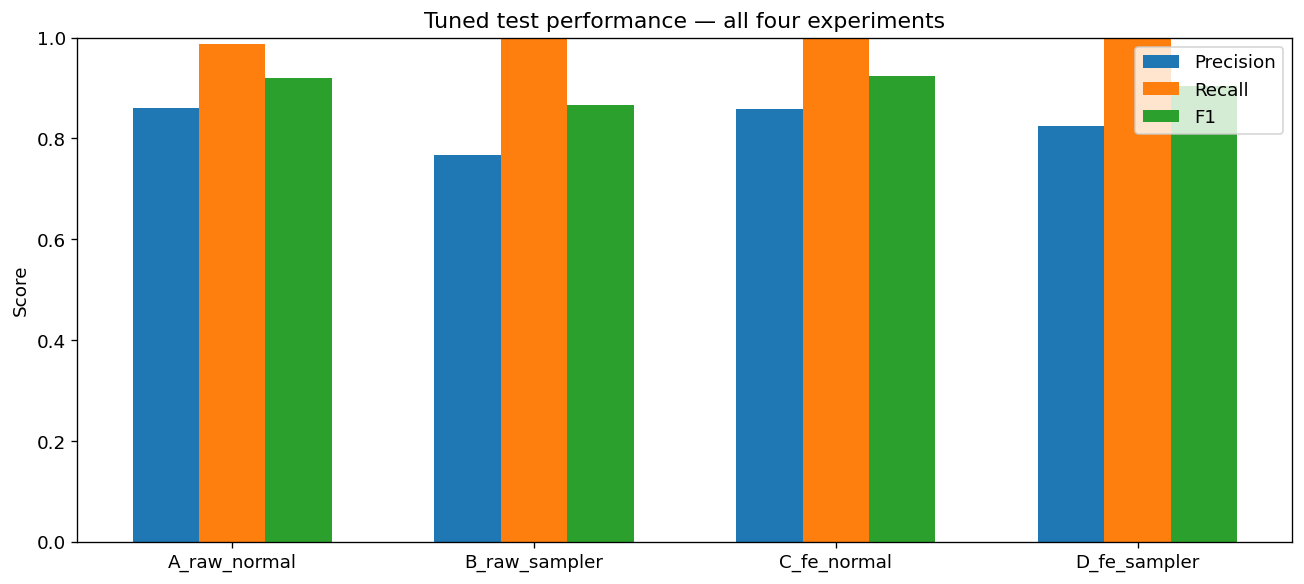

In [44]:
metrics_plot  = ["tuned_test_precision","tuned_test_recall","tuned_test_f1"]
metric_labels = ["Precision","Recall","F1"]
x = np.arange(len(comparison_df["model"])); width = 0.22
plt.figure(figsize=(11, 5))
for i, metric in enumerate(metrics_plot):
    plt.bar(x + i*width, comparison_df[metric], width, label=metric_labels[i])
plt.xticks(x + width, comparison_df["model"])
plt.ylabel("Score"); plt.title("Tuned test performance — all four experiments")
plt.legend(); plt.ylim(0, 1); plt.tight_layout(); plt.show()


## Expected cost comparison

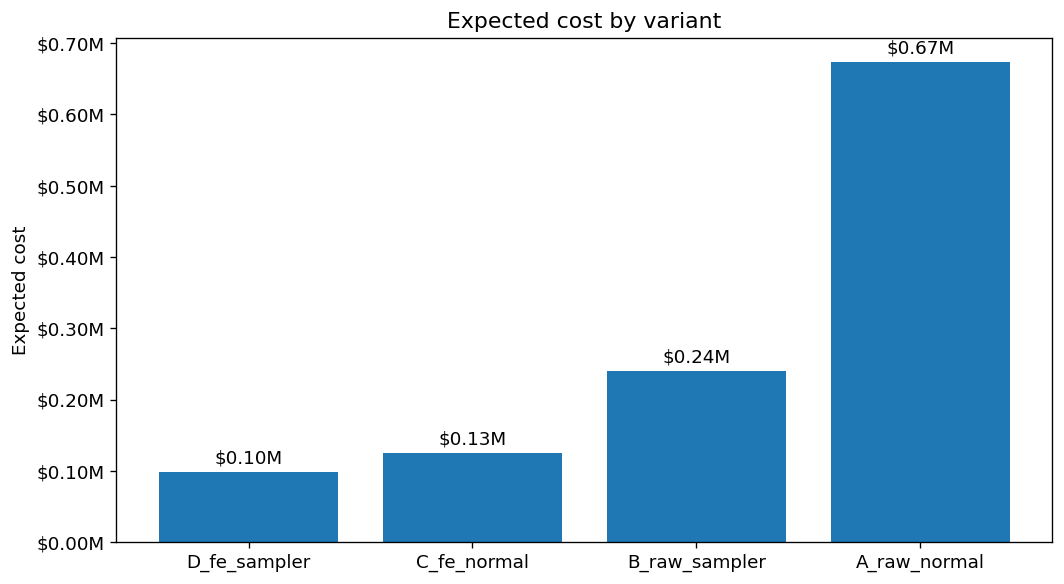

In [45]:
cost_plot_df = comparison_df.sort_values("tuned_expected_cost")
plt.figure(figsize=(9, 5))
bars = plt.bar(cost_plot_df["model"], cost_plot_df["tuned_expected_cost"])
plt.title("Expected cost by variant")
plt.ylabel("Expected cost")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
plt.bar_label(bars,
    labels=[f"${v/1_000_000:.2f}M" for v in cost_plot_df["tuned_expected_cost"]],
    padding=3)
plt.tight_layout(); plt.show()


## Threshold performance plot

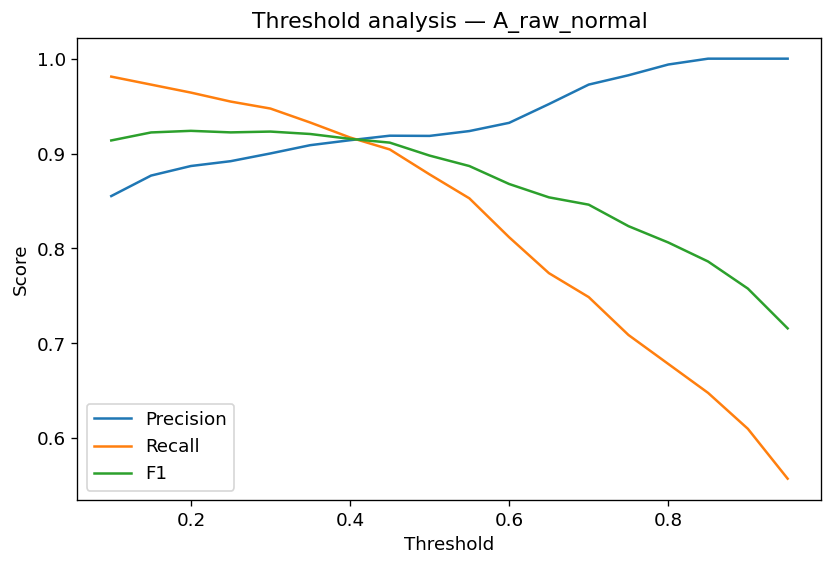

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results_A_raw_normal["threshold"],
         threshold_results_A_raw_normal["precision"], label="Precision")
plt.plot(threshold_results_A_raw_normal["threshold"],
         threshold_results_A_raw_normal["recall"],    label="Recall")
plt.plot(threshold_results_A_raw_normal["threshold"],
         threshold_results_A_raw_normal["f1"],        label="F1")
plt.title("Threshold analysis — A_raw_normal")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.legend(); plt.show()


## Tuned confusion matrices

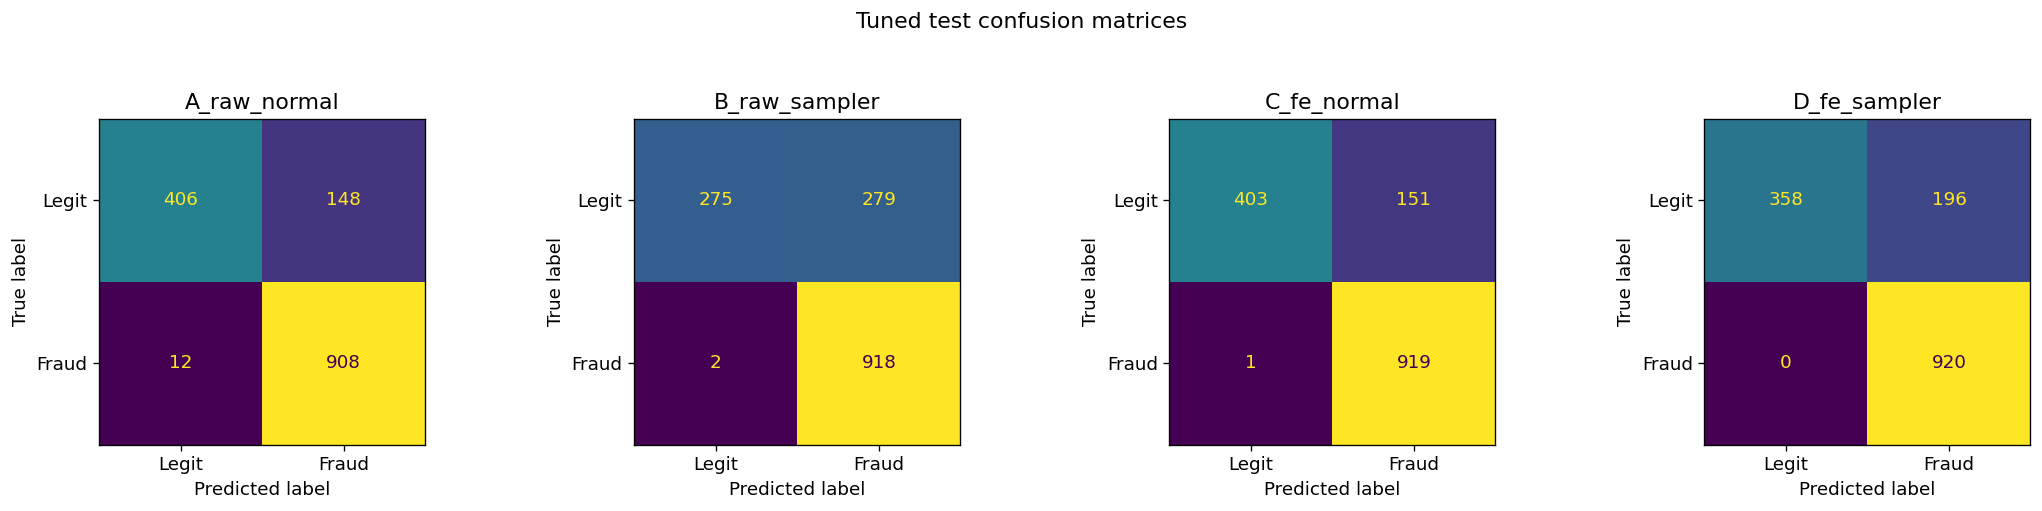

In [47]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (cm, title_) in zip(axes, [(tuned_cm_A_raw_normal, "A_raw_normal"), (tuned_cm_B_raw_sampler, "B_raw_sampler"), (tuned_cm_C_fe_normal, "C_fe_normal"), (tuned_cm_D_fe_sampler, "D_fe_sampler")]):
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit","Fraud"]).plot(
        ax=ax, colorbar=False, values_format="d")
    ax.set_title(title_)
plt.suptitle("Tuned test confusion matrices", y=1.05)
plt.tight_layout(); plt.show()


## Threshold analysis — precision, recall, F1

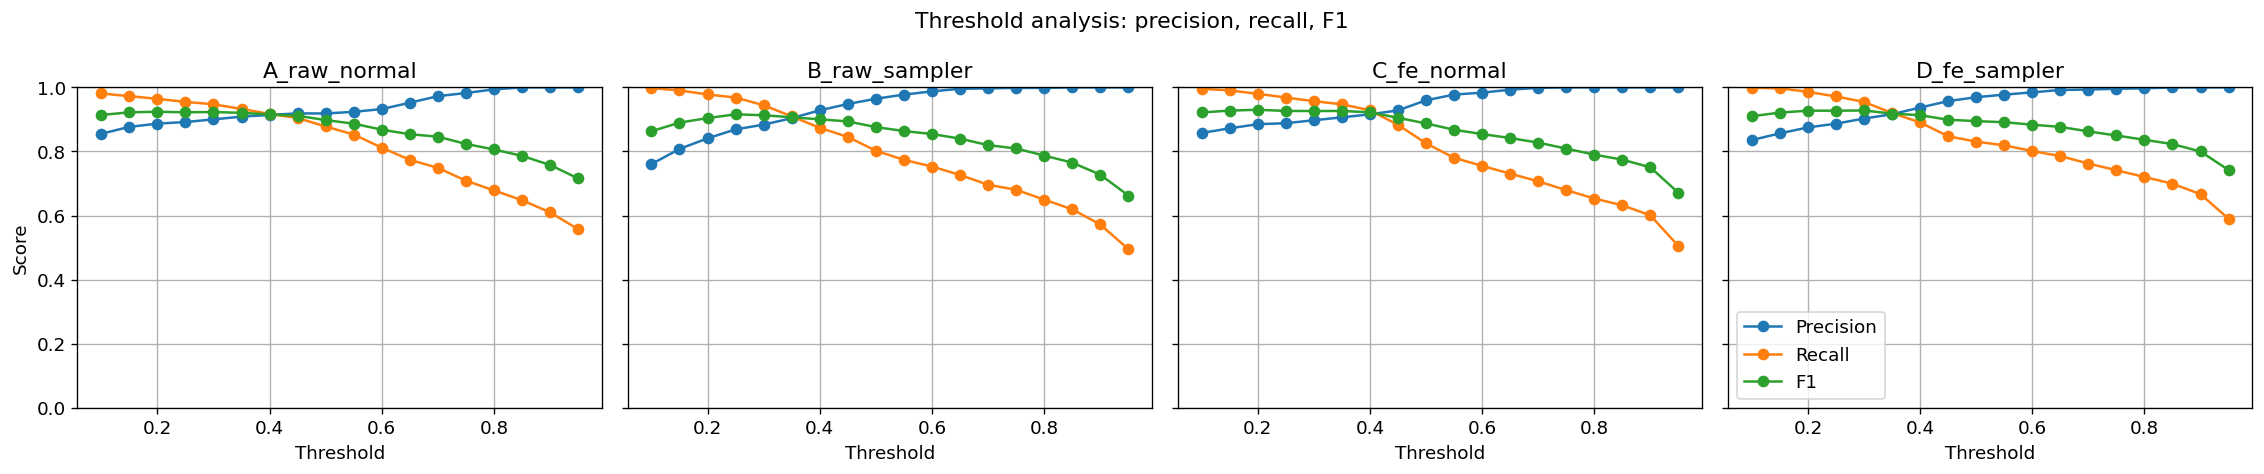

In [48]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4), sharey=True)
for ax, (df, title_) in zip(axes, [(threshold_results_A_raw_normal, "A_raw_normal"), (threshold_results_B_raw_sampler, "B_raw_sampler"), (threshold_results_C_fe_normal, "C_fe_normal"), (threshold_results_D_fe_sampler, "D_fe_sampler")]):
    ax.plot(df["threshold"], df["precision"], marker="o", label="Precision")
    ax.plot(df["threshold"], df["recall"],    marker="o", label="Recall")
    ax.plot(df["threshold"], df["f1"],        marker="o", label="F1")
    ax.set_title(title_); ax.set_xlabel("Threshold"); ax.set_ylim(0, 1); ax.grid(True)
axes[0].set_ylabel("Score"); axes[-1].legend(loc="best")
plt.suptitle("Threshold analysis: precision, recall, F1")
plt.tight_layout(); plt.show()


## Expected cost by threshold

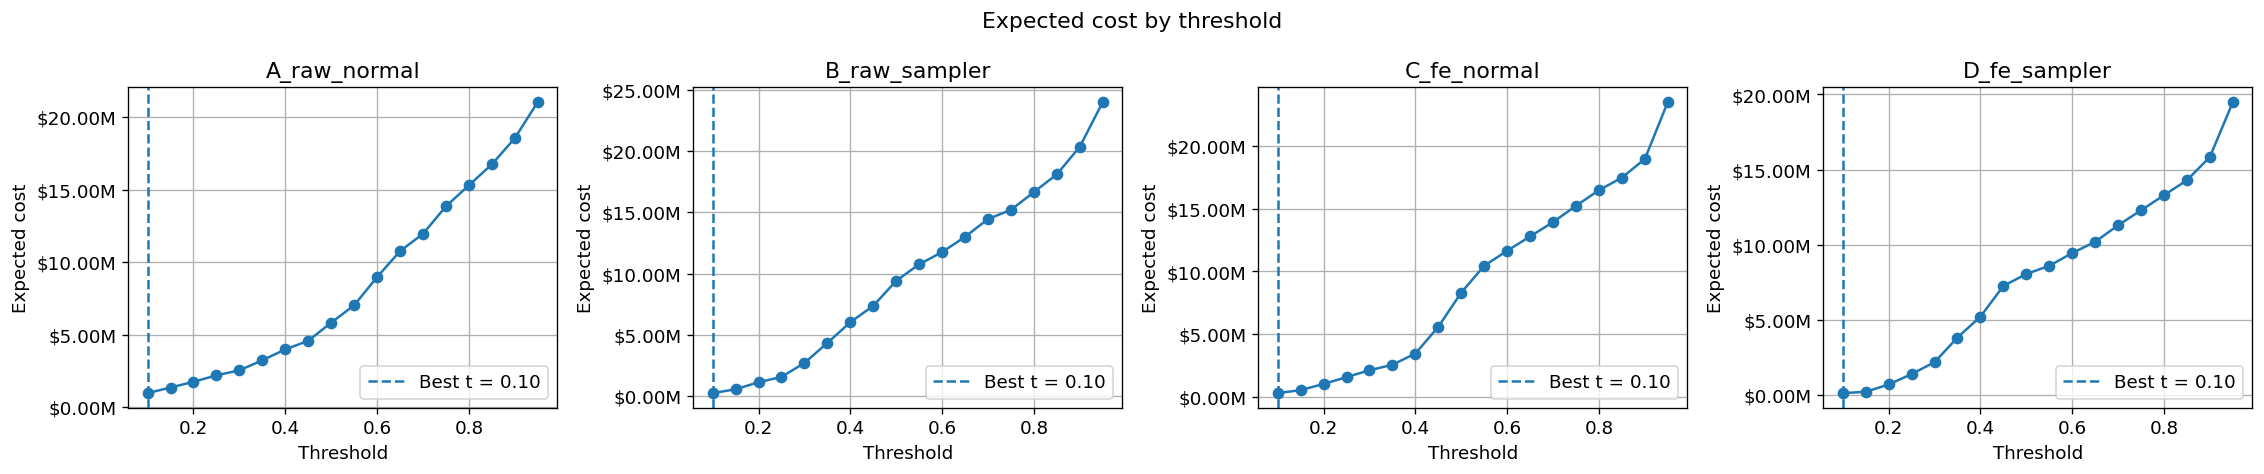

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4), sharey=False)
for ax, (df, title_) in zip(axes, [(cost_df_A_raw_normal, "A_raw_normal"), (cost_df_B_raw_sampler, "B_raw_sampler"), (cost_df_C_fe_normal, "C_fe_normal"), (cost_df_D_fe_sampler, "D_fe_sampler")]):
    df_sorted = df.sort_values("threshold")
    best_row  = df.loc[df["expected_cost"].idxmin()]
    ax.plot(df_sorted["threshold"], df_sorted["expected_cost"], marker="o")
    ax.axvline(best_row["threshold"], linestyle="--",
               label=f"Best t = {best_row['threshold']:.2f}")
    ax.set_title(title_); ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
    ax.grid(True); ax.legend()
plt.suptitle("Expected cost by threshold")
plt.tight_layout(); plt.show()


## Precision-Recall curves

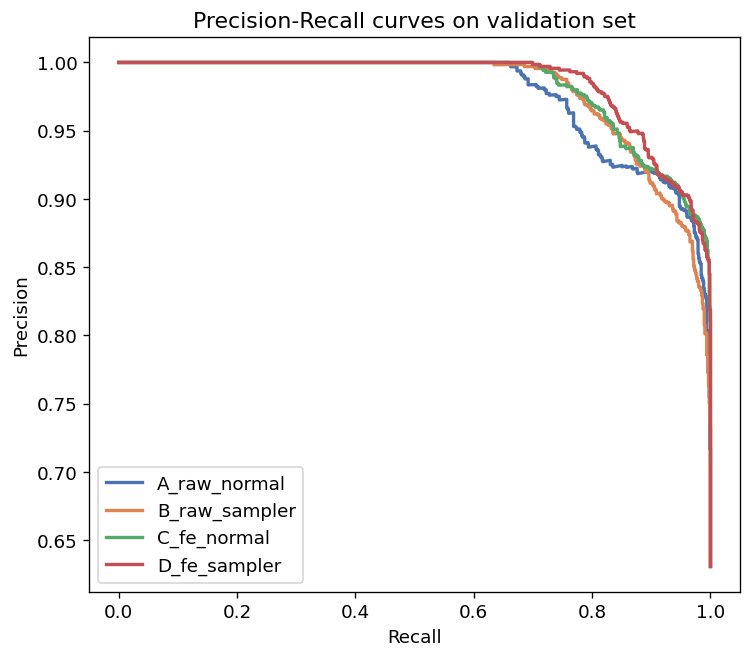

In [50]:
from sklearn.metrics import precision_recall_curve
p_0, r_0, _ = precision_recall_curve(val_y_A_raw_normal, val_p_A_raw_normal)
p_1, r_1, _ = precision_recall_curve(val_y_B_raw_sampler, val_p_B_raw_sampler)
p_2, r_2, _ = precision_recall_curve(val_y_C_fe_normal, val_p_C_fe_normal)
p_3, r_3, _ = precision_recall_curve(val_y_D_fe_sampler, val_p_D_fe_sampler)
plt.figure(figsize=(7, 6))
plt.plot(r_0, p_0, color='#4C72B0', lw=2, label="A_raw_normal")
plt.plot(r_1, p_1, color='#DD8452', lw=2, label="B_raw_sampler")
plt.plot(r_2, p_2, color='#55A868', lw=2, label="C_fe_normal")
plt.plot(r_3, p_3, color='#C44E52', lw=2, label="D_fe_sampler")
plt.title("Precision-Recall curves on validation set")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.show()


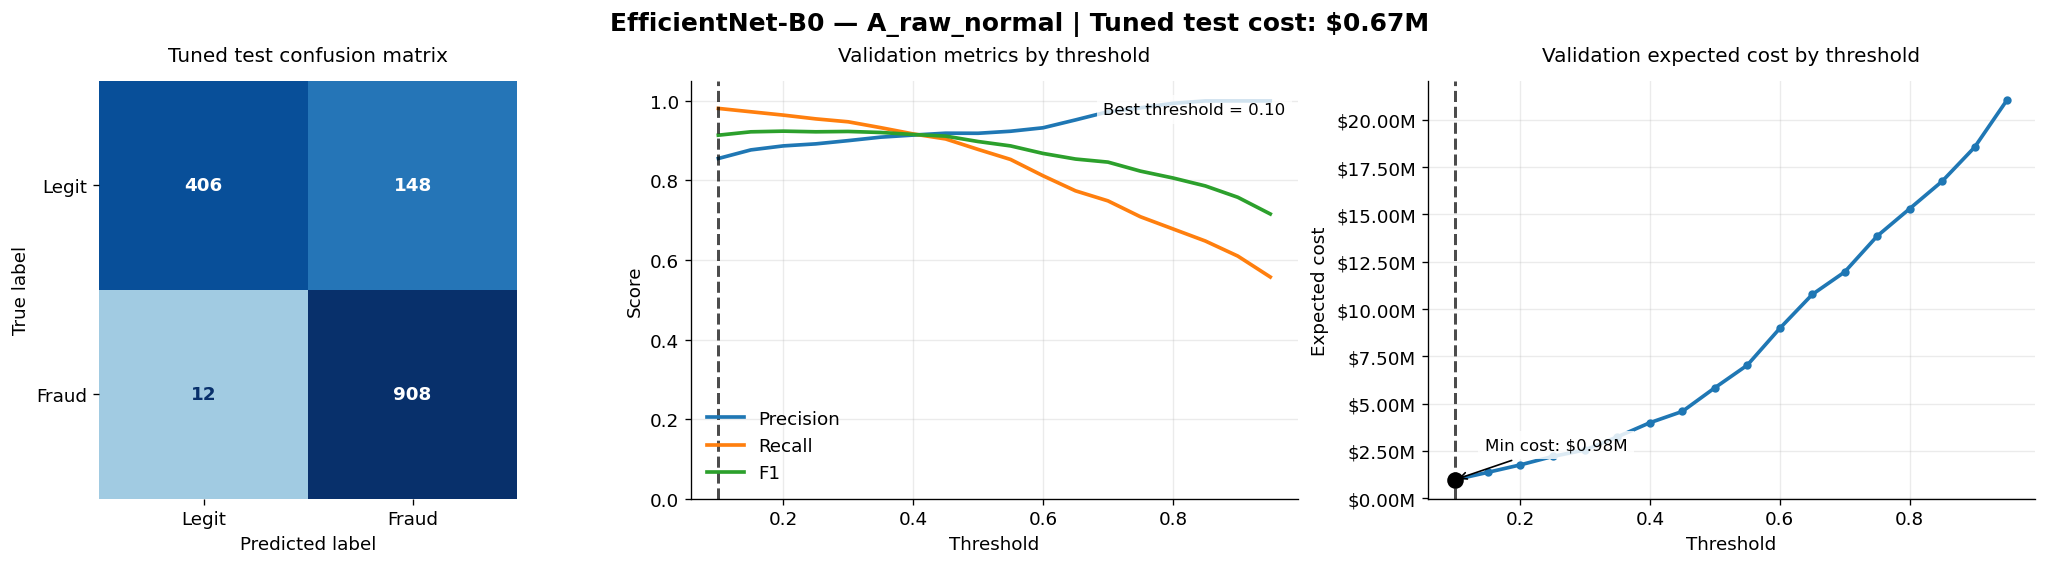

In [51]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_A_raw_normal,
    threshold_results=threshold_results_A_raw_normal,
    cost_df=cost_df_A_raw_normal,
    model_name="EfficientNet-B0 — A_raw_normal",
    save_path=RESULTS_BASE / "diagnostics_A_raw_normal.png",
)


EfficientNet-B0 A_raw_normal achieves a tuned test cost of about $0.67M. It detects 908 fraud cases and misses 12, while correctly identifying 406 legitimate cases. The model does not collapse into an all-fraud classifier, but the missed fraud cases make its expected cost higher than the feature-engineered and sampler-based variants.

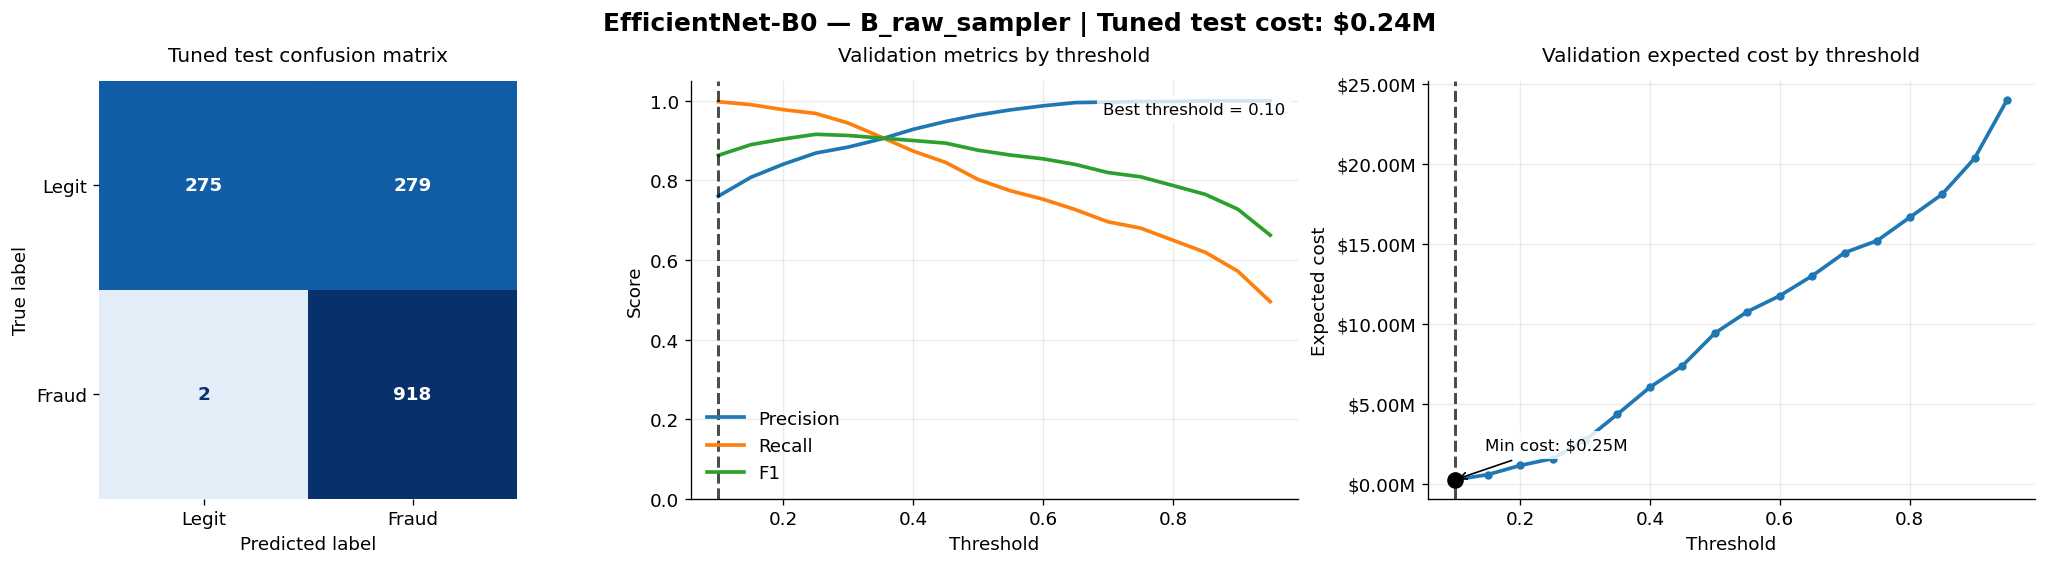

In [52]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_B_raw_sampler,
    threshold_results=threshold_results_B_raw_sampler,
    cost_df=cost_df_B_raw_sampler,
    model_name="EfficientNet-B0 — B_raw_sampler",
    save_path=RESULTS_BASE / "diagnostics_B_raw_sampler.png",
)


EfficientNet-B0 B_raw_sample achieves a tuned test cost of about $0.24M. It misses only 2 fraud cases, compared with 12 for A_raw_normal, although it produces more false positives. Because false negatives are much more expensive, this trade-off substantially reduces expected cost. This shows that group-balanced sampling improves the raw-feature EfficientNet-B0 multimodal model from a cost-sensitive perspective.

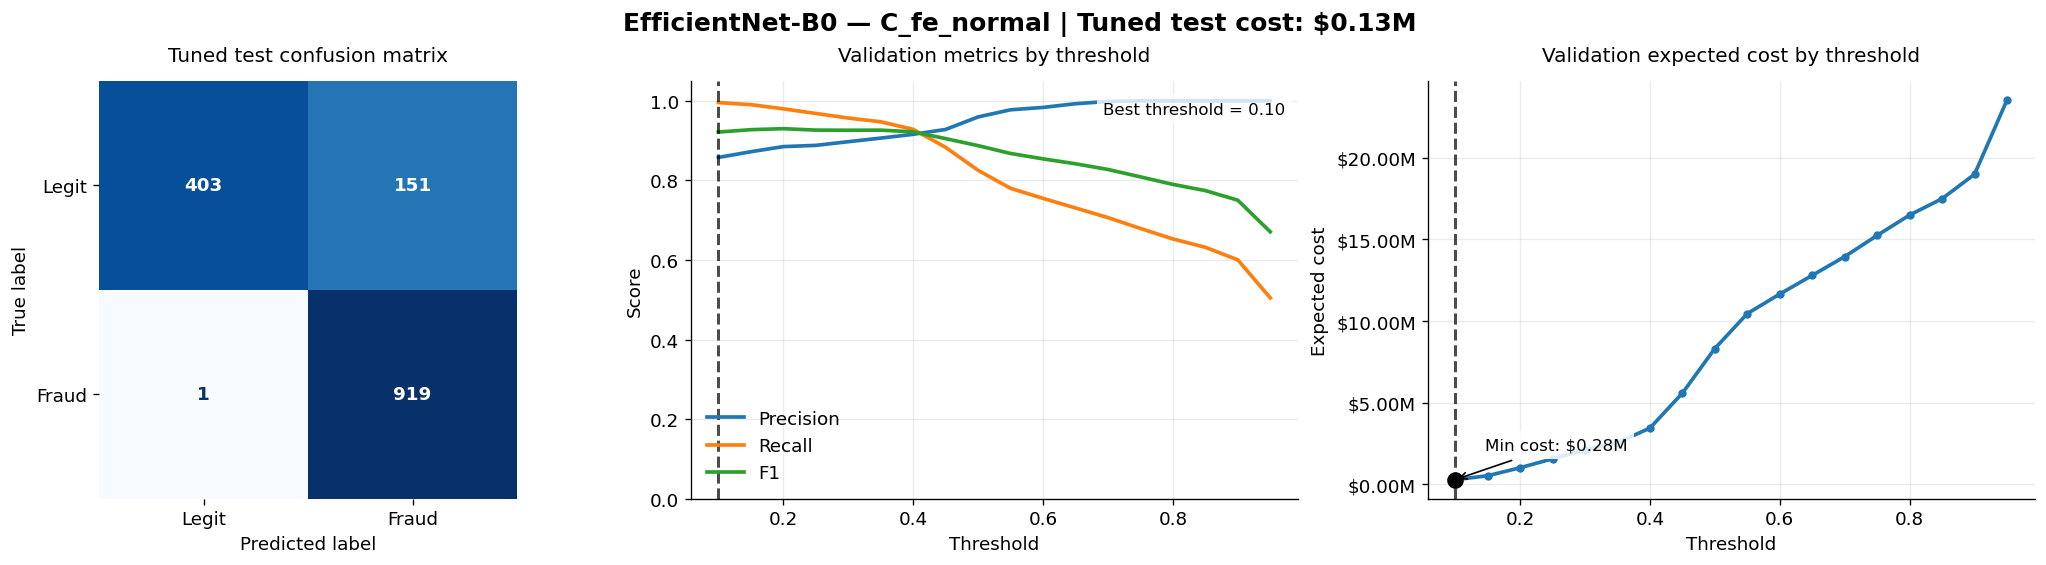

In [53]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_C_fe_normal,
    threshold_results=threshold_results_C_fe_normal,
    cost_df=cost_df_C_fe_normal,
    model_name="EfficientNet-B0 — C_fe_normal",
    save_path=RESULTS_BASE / "diagnostics_C_fe_normal.png",
)


EfficientNet-B0 C_fe_normal achieves a tuned test cost of about $0.13M. It misses only 1 fraud case and correctly identifies 403 legitimate cases. Compared with the raw-feature variants, engineered features reduce missed fraud while preserving strong legitimate-class detection. This makes C_fe_normal one of the strongest EfficientNet-B0 multimodal variants.

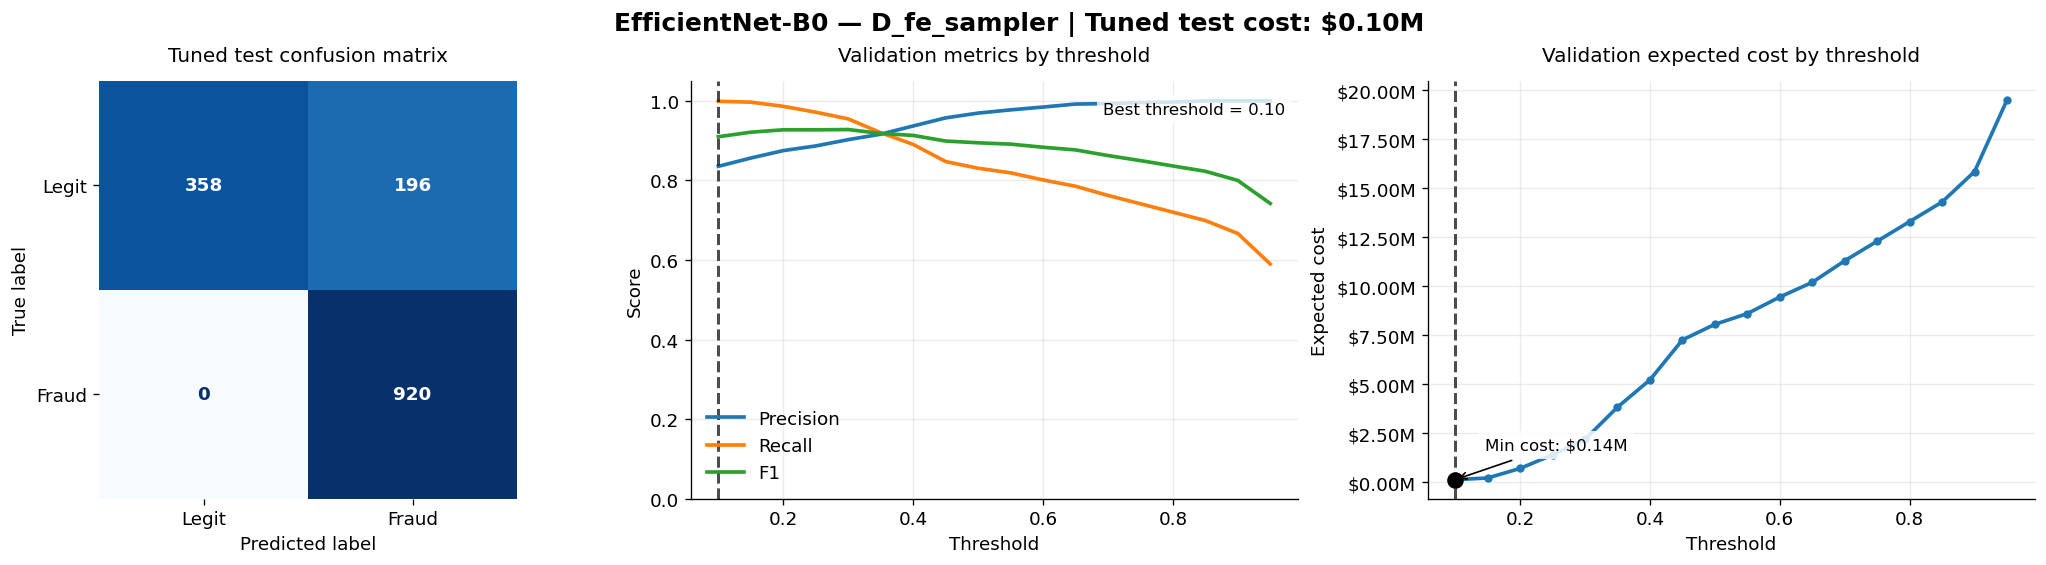

In [54]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_D_fe_sampler,
    threshold_results=threshold_results_D_fe_sampler,
    cost_df=cost_df_D_fe_sampler,
    model_name="EfficientNet-B0 — D_fe_sampler",
    save_path=RESULTS_BASE / "diagnostics_D_fe_sampler.png",
)


EfficientNet-B0 D_fe_sampler achieves the lowest tuned test cost, about $0.10M. It detects all fraud cases and produces zero false negatives, while still correctly identifying 358 legitimate cases. Compared with C_fe_normal, it accepts more false positives but removes the remaining missed fraud case, making it the best EfficientNet-B0 variant under the cost-sensitive objective.

## Training curves

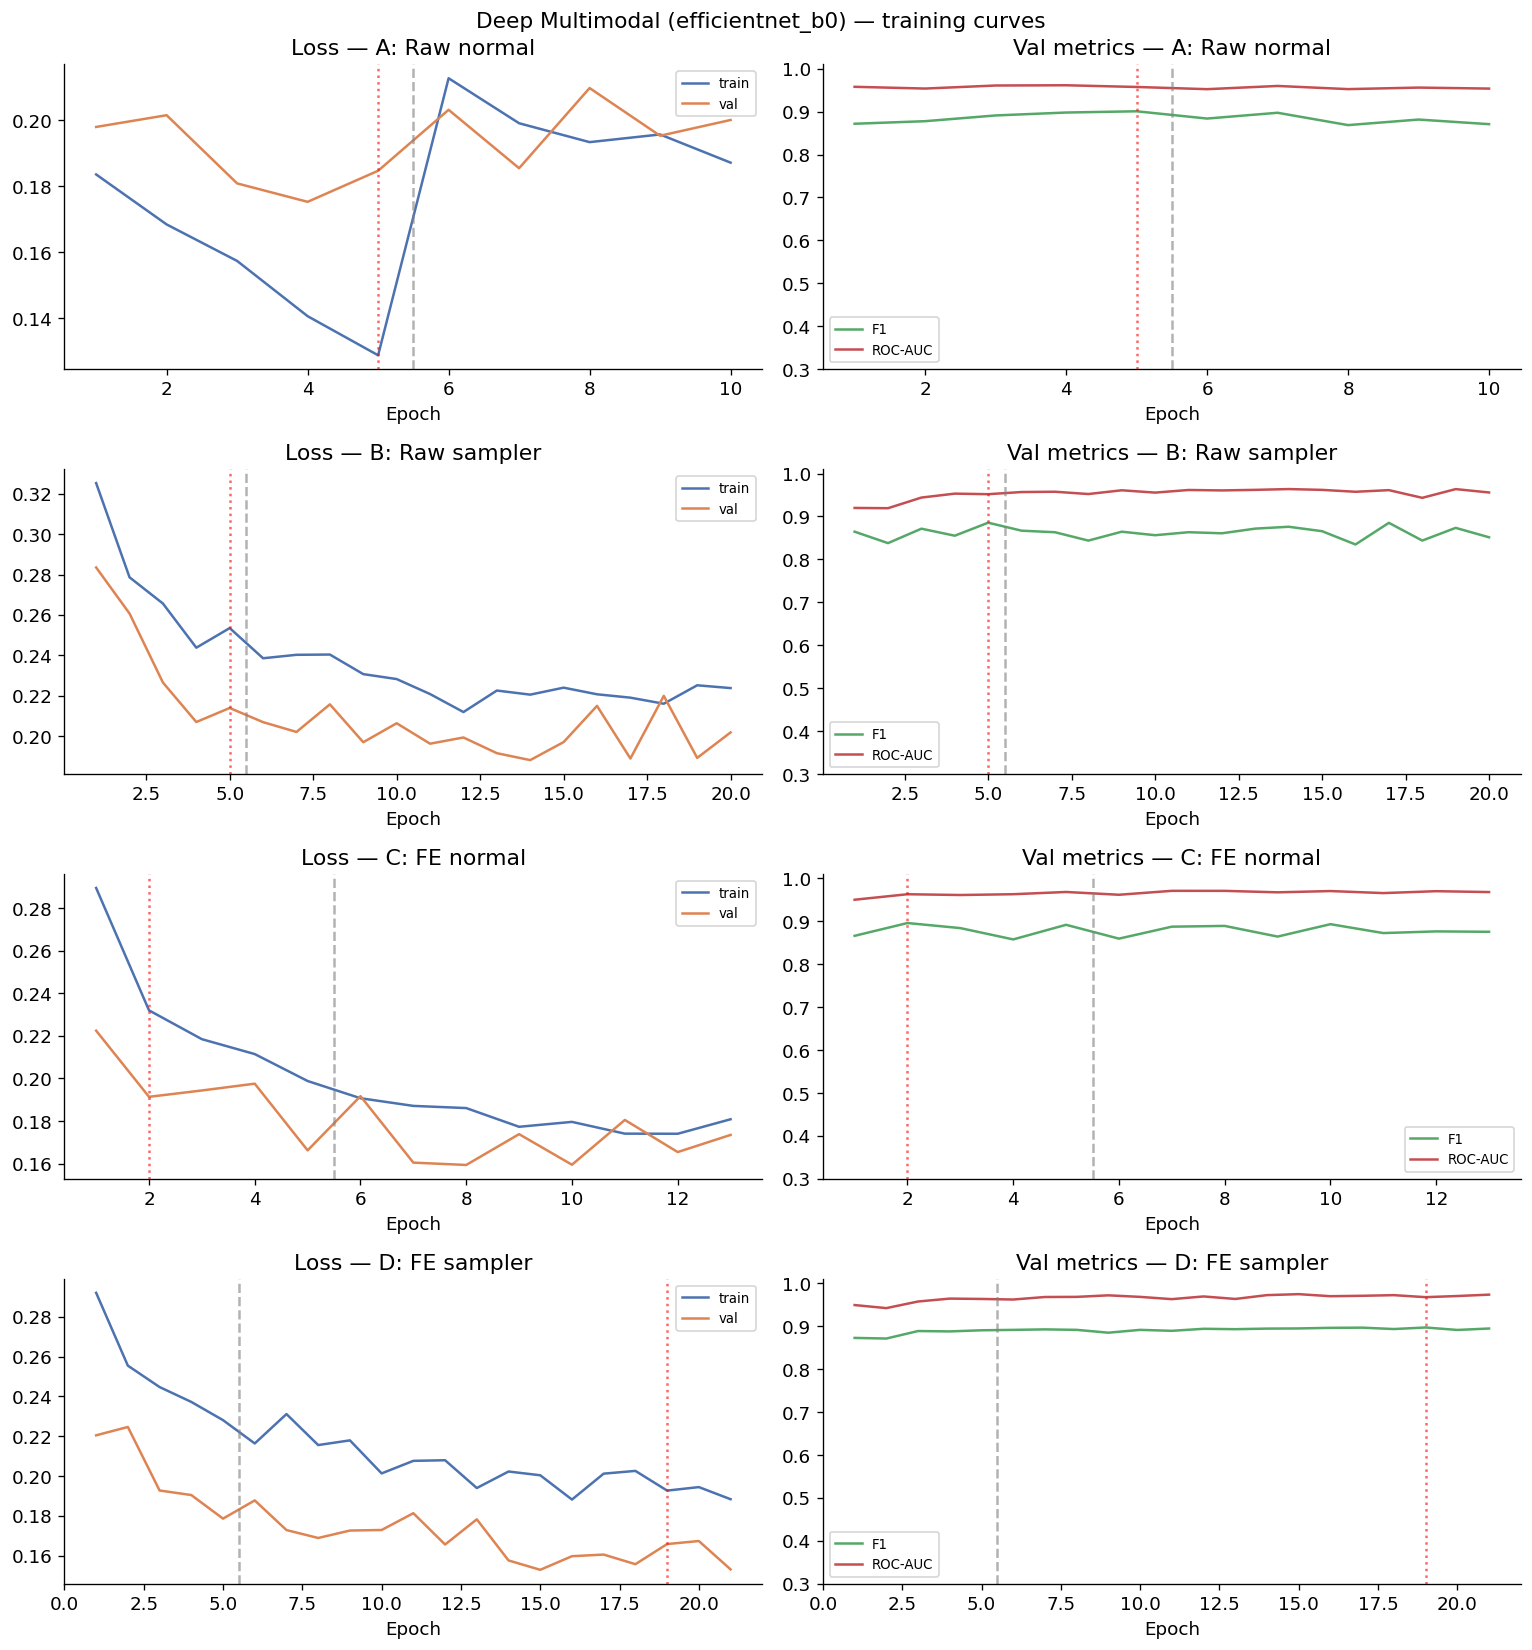

In [55]:
fig, axes = plt.subplots(4, 2, figsize=(13, 14))
labels_all = ["A: Raw normal","B: Raw sampler","C: FE normal","D: FE sampler"]
for row, (exp_id, label) in enumerate(zip(EXP_DIRS.keys(), labels_all)):
    hist_path = EXP_DIRS[exp_id] / "training_history.csv"
    if not hist_path.exists():
        print(f"No history for {exp_id}"); continue
    hist = pd.read_csv(hist_path)
    if "epoch_global" not in hist.columns:
        hist["epoch_global"] = range(1, len(hist)+1)
    ep      = hist["epoch_global"]
    best_ep = ep.iloc[hist["val_f1"].dropna().idxmax()] if not hist["val_f1"].dropna().empty else None

    axes[row,0].plot(ep, hist["train_loss"], label="train", color="#4C72B0")
    axes[row,0].plot(ep, hist["val_loss"],   label="val",   color="#DD8452")
    axes[row,0].set_title(f"Loss — {label}"); axes[row,0].legend(fontsize=8)

    axes[row,1].plot(ep, hist["val_f1"],      label="F1",      color="#55A868")
    axes[row,1].plot(ep, hist["val_roc_auc"], label="ROC-AUC", color="#C44E52")
    axes[row,1].set_ylim(0.3, 1.01)
    axes[row,1].set_title(f"Val metrics — {label}"); axes[row,1].legend(fontsize=8)

    for ax in axes[row]:
        ax.axvline(x=STAGE1_EPOCHS+0.5, color="gray", linestyle="--", alpha=0.6, label="stage 1→2")
        if best_ep is not None:
            ax.axvline(x=best_ep, color="red", linestyle=":", alpha=0.6, label="best val F1")
        ax.set_xlabel("Epoch"); ax.spines[["top","right"]].set_visible(False)

fig.suptitle(f"Deep Multimodal ({BACKBONE}) — training curves", fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS_BASE / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## Subgroup analysis by combo_type

The key thesis diagnostic. Image-only models scored tab1_img0 F1 ≈ 0.30.
Multimodal fusion should recover this group substantially.


In [56]:
results = [
    {"id":"A_raw_normal",  "sg":sg_A_raw_normal,  "threshold":best_threshold_A_raw_normal,  "y_true":test_y_A_raw_normal,  "y_prob":test_p_A_raw_normal},
    {"id":"B_raw_sampler", "sg":sg_B_raw_sampler, "threshold":best_threshold_B_raw_sampler, "y_true":test_y_B_raw_sampler, "y_prob":test_p_B_raw_sampler},
    {"id":"C_fe_normal",   "sg":sg_C_fe_normal,   "threshold":best_threshold_C_fe_normal,   "y_true":test_y_C_fe_normal,   "y_prob":test_p_C_fe_normal},
    {"id":"D_fe_sampler",  "sg":sg_D_fe_sampler,  "threshold":best_threshold_D_fe_sampler,  "y_true":test_y_D_fe_sampler,  "y_prob":test_p_D_fe_sampler},
]
labels_all = [r["id"] for r in results]


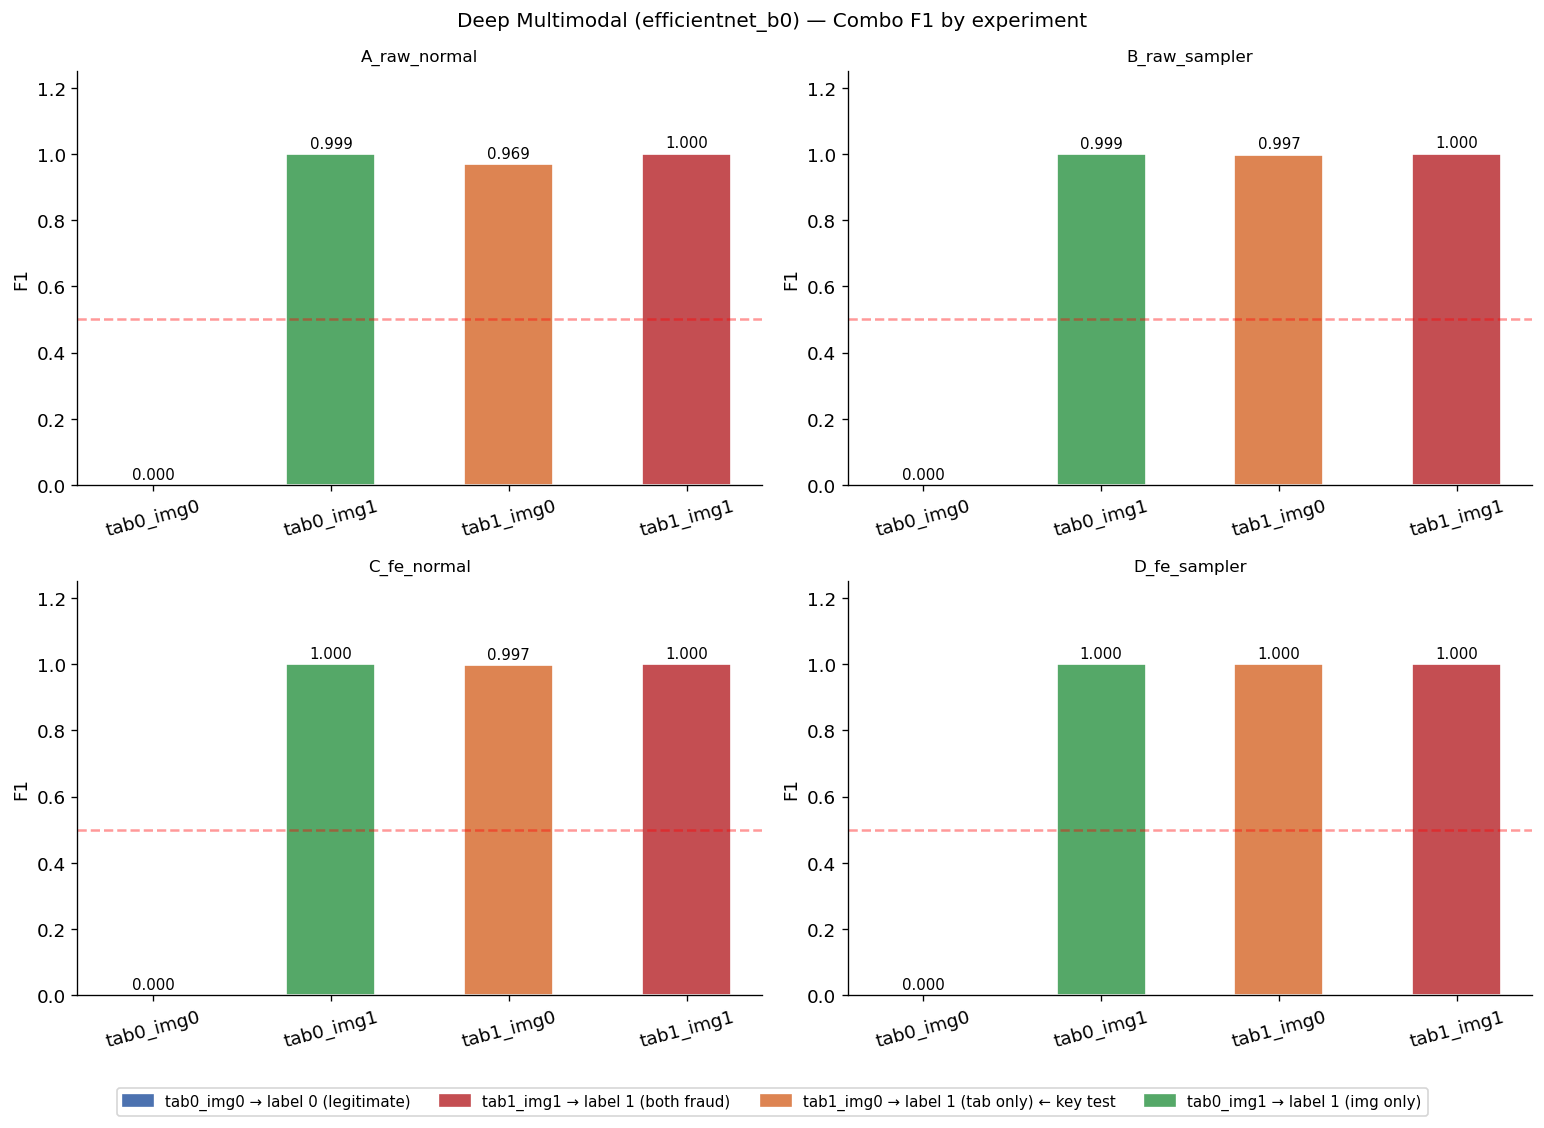

,A_raw_normal,B_raw_sampler,C_fe_normal,D_fe_sampler
combo_type,,,,
tab0_img0,0.000,0.000,0.000,0.0
tab0_img1,0.999,0.999,1.000,1.0
tab1_img0,0.969,0.997,0.997,1.0
tab1_img1,1.000,1.000,1.000,1.0


In [57]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, r, label in zip(axes.flat, results, labels_all):
    sg   = r["sg"]
    clrs = [COMBO_COLOURS.get(c,"gray") for c in sg["combo_type"]]
    bars = ax.bar(sg["combo_type"], sg["f1"], color=clrs, edgecolor="white", width=0.5)
    for bar, val in zip(bars, sg["f1"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 1.25); ax.set_title(label, fontsize=10)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.4)
    ax.set_ylabel("F1"); ax.tick_params(axis="x", rotation=15)
    ax.spines[["top","right"]].set_visible(False)
fig.legend(handles=[
    Patch(color="#4C72B0", label="tab0_img0 → label 0 (legitimate)"),
    Patch(color="#C44E52", label="tab1_img1 → label 1 (both fraud)"),
    Patch(color="#DD8452", label="tab1_img0 → label 1 (tab only) ← key test"),
    Patch(color="#55A868", label="tab0_img1 → label 1 (img only)"),
], loc="lower center", ncol=4, bbox_to_anchor=(0.5,-0.05), fontsize=9)
fig.suptitle(f"Deep Multimodal ({BACKBONE}) — Combo F1 by experiment", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_BASE / "subgroup_combo.png", dpi=150, bbox_inches="tight")
plt.show()
sg_cmp = pd.concat([
    r["sg"].set_index("combo_type")[["f1"]].rename(columns={"f1":r["id"]})
    for r in results], axis=1).round(3)
display(sg_cmp)
sg_cmp.to_csv(RESULTS_BASE / "subgroup_comparison.csv")


## Per-combo diagnostics

In [58]:
from sklearn.metrics import f1_score, accuracy_score

def combo_metrics_fixed(res):
    df   = res["pred_df"] if "pred_df" in res else pd.DataFrame(
           {"y_true": res["y_true"], "y_prob": res["y_prob"],
            "y_pred": (res["y_prob"] >= res["threshold"]).astype(int)})
    rows = {}
    for combo, g in df.groupby("combo_type"):
        y_true = g["y_true"]; y_pred = g["y_pred"]
        acc    = accuracy_score(y_true, y_pred)
        if combo == "tab0_img0":
            legit_f1 = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
            fp       = ((y_true==0)&(y_pred==1)).sum()
            n_legit  = (y_true==0).sum()
            fpr      = fp/n_legit if n_legit > 0 else float("nan")
            rows["tab0_img0_acc"] = acc; rows["tab0_img0_legit_f1"] = legit_f1; rows["tab0_img0_fpr"] = fpr
        elif combo == "tab1_img0":
            rows["tab1_img0_f1"] = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
            rows["tab1_img0_acc"] = acc
        else:
            rows[f"{combo}_acc"] = acc
    return rows


In [59]:
summary_rows = []
for res, feat, samp in [
    (results[0], "Raw",        "No"),
    (results[1], "Raw",        "Yes"),
    (results[2], "Engineered", "No"),
    (results[3], "Engineered", "Yes"),
]:
    m = {"accuracy": val_metrics_A_raw_normal["accuracy"],
         "precision": tuned_metrics_A_raw_normal["precision"],
         "recall": tuned_metrics_A_raw_normal["recall"],
         "f1": tuned_metrics_A_raw_normal["f1"],
         "roc_auc": val_metrics_A_raw_normal["roc_auc"]}
    m = {k: (test_metrics_A_raw_normal if res["id"]=="A_raw_normal"
         else test_metrics_B_raw_sampler if res["id"]=="B_raw_sampler"
         else test_metrics_C_fe_normal if res["id"]=="C_fe_normal"
         else test_metrics_D_fe_sampler)[k] for k in ["accuracy","precision","recall","f1","roc_auc"]}
    combo = combo_metrics_fixed(res)
    summary_rows.append({
        "Experiment": res["id"], "Features": feat, "Sampler": samp,
        "Threshold": res["threshold"],
        "Accuracy": m["accuracy"], "Precision": m["precision"],
        "Recall": m["recall"], "F1": m["f1"], "ROC-AUC": m["roc_auc"],
        "tab0_img0 Legit F1": combo.get("tab0_img0_legit_f1"),
        "tab0_img0 FPR":      combo.get("tab0_img0_fpr"),
        "tab1_img0 Fraud F1": combo.get("tab1_img0_f1"),
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(4))


KeyError: 'combo_type'

## Final choice

In [61]:
comparison_df.to_csv(RESULTS_BASE / "comparison.csv", index=False)
print("Saved comparison to:", RESULTS_BASE / "comparison.csv")
final_choice_df = comparison_df.sort_values("tuned_expected_cost").copy()
print("Best variant:", final_choice_df.iloc[0]["model"])
final_choice_df


Saved comparison to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_efficientnet_b0\comparison.csv
Best variant: D_fe_sampler


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
3,D_fe_sampler,0.894677,0.974575,0.985300,0.900292,0.975961,0.985868,0.1,0.824373,1.000000,0.903733,98000
2,C_fe_normal,0.887507,0.971007,0.982926,0.901278,0.978076,0.986811,0.1,0.858879,0.998913,0.923618,125500
1,B_raw_sampler,0.876005,0.963838,0.979575,0.881416,0.965151,0.979943,0.1,0.766917,0.997826,0.867265,239500
0,A_raw_normal,0.897849,0.961391,0.977243,0.913567,0.969294,0.981780,0.1,0.859848,0.986957,0.919028,674000
